In [1]:
import time
import tqdm
import numpy as np
#import uncertainties as uc
#from uncertainties.umath import *
import astropy
import scipy.signal as sig
import seaborn as sns
import scipy.interpolate as interp
from scipy.stats import gaussian_kde
from astropy.table import QTable
from astropy import units as u, constants as consts
from astropy.visualization import quantity_support
from astropy import cosmology
quantity_support()
import matplotlib.pyplot as plt
from matplotlib.path import Path
# import scipy.optimize as opt
# import matplotlib.patches as patches
#import colour
#Color = colour.Color
import pandas as pd
import pickle
from scipy.interpolate import UnivariateSpline
import random
from scipy.stats import norm
import glob
# from scipy import stats
# from scipy.odr import ODR, Model, Data, RealData
# import scipy.interpolate as interp
# from astropy.io import fits
# from astropy.utils.data import download_file
#%matplotlib inline

#import matplotlib as plt
plt.rcParams.keys()
plt.rc('font', family='serif')
params = {
    'axes.labelsize': 20,
     'axes.titlesize':25,
   'axes.linewidth': 1.5,
   'legend.fontsize': 25,
   'legend.frameon': False,
   'lines.linewidth': 2,
   'xtick.direction': 'in',
   'xtick.labelsize': 20,
   'xtick.major.bottom': True,
   'xtick.major.pad': 10,
   'xtick.major.size': 10,
   'xtick.major.width': 1,
   'xtick.minor.bottom': True,
   'xtick.minor.pad': 3.5,
   'xtick.minor.size': 5,
   'xtick.minor.top': True,
   'xtick.minor.visible': True,
   'xtick.minor.width': 1,
   'xtick.top': True,
   'ytick.direction': 'in',
    'ytick.labelsize': 12,
   'ytick.major.pad': 10,
   'ytick.major.size': 10,
   'ytick.major.width': 1,
   'ytick.minor.pad': 3.5,
   'ytick.minor.size': 5,
   'ytick.minor.visible': True,
   'ytick.minor.width': 1,
   'ytick.right': True,
   'text.usetex': True,
    'legend.fontsize': 10,
   'figure.figsize': [10,10], # instead of 4.5, 4.5
   'savefig.format': 'eps'
   }
plt.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
from astropy.io import fits

from scipy.stats import norm
import glob
from scipy import interpolate
from scipy import integrate
from scipy.integrate import solve_ivp
from astropy import cosmology
LCDM = cosmology.LambdaCDM(H0=70, Om0=0.3, Ode0=0.7) # Astropy built-in cosmology 


%matplotlib inline

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
"""
Cooling curve as a function of density, temperature, metallicity, redshift
"""


def cooling_fn_generator():
    file = glob.glob("./tables/Lambda_tab_redshifts.npz")
    if len(file) > 0:
        print("reading file", file)
        data = np.load(file[0])
        Lambda_tab = data["Lambda_tab"]
        redshifts = data["redshifts"]
        Zs = data["Zs"]
        log_Tbins = data["log_Tbins"]
        log_nHbins = data["log_nHbins"]
        Lambda = interpolate.RegularGridInterpolator(
            (log_nHbins, log_Tbins, Zs, redshifts),
            Lambda_tab,
            bounds_error=False,
            fill_value=1e-30,
        )
    else:
        files = np.sort(glob.glob("z_*hdf5"))  ## CHANGE FOR WHERE YOU WANT TO KEEP IT
        redshifts = np.array([float(f[-10:-5]) for f in files])
        HHeCooling = {}
        ZCooling = {}
        TE_T_n = {}
        for i in range(len(files)):
            f = h5py.File(files[i], "r")
            i_X_He = -3
            Metal_free = f.get("Metal_free")
            Total_Metals = f.get("Total_Metals")
            log_Tbins = np.array(np.log10(Metal_free["Temperature_bins"]))
            log_nHbins = np.array(np.log10(Metal_free["Hydrogen_density_bins"]))
            Cooling_Metal_free = np.array(Metal_free["Net_Cooling"])[
                i_X_He
            ]  ##### what Helium_mass_fraction to use    Total_Metals = f.get('Total_Metals')
            Cooling_Total_Metals = np.array(Total_Metals["Net_cooling"])
            HHeCooling[redshifts[i]] = interpolate.RectBivariateSpline(
                log_Tbins, log_nHbins, Cooling_Metal_free
            )
            ZCooling[redshifts[i]] = interpolate.RectBivariateSpline(
                log_Tbins, log_nHbins, Cooling_Total_Metals
            )
            f.close()
        Lambda_tab = np.array(
            [
                [
                    [
                        [
                            HHeCooling[zz].ev(lT, ln) + Z * ZCooling[zz].ev(lT, ln)
                            for zz in redshifts
                        ]
                        for Z in Zs
                    ]
                    for lT in log_Tbins
                ]
                for ln in log_nHbins
            ]
        )
        np.savez(
            "./data/Lambda_tab_redshifts.npz",
            Lambda_tab=Lambda_tab,
            redshifts=redshifts,
            Zs=Zs,
            log_Tbins=log_Tbins,
            log_nHbins=log_nHbins,
        )
        Lambda = interpolate.RegularGridInterpolator(
            (log_nHbins, log_Tbins, Zs, redshifts),
            Lambda_tab,
            bounds_error=False,
            fill_value=0,
        )
        print("interpolated lambda")
    return Lambda


cooling_fn = cooling_fn_generator()

reading file ['./tables/Lambda_tab_redshifts.npz']


# Ordinary Differential Equations for Analytic Modeling of Baryonic Flow Rates in Galaxies

In [ ]:
def mass_evolution(t, mass):
    #  t: time (units: Gyr)
    #  mass [0-4] (units: solar mass): 5 vector of mass of each component/term
    #  energy [5-9] (units: erg): 5 vector of energy of each component/term

    mgas = mass[0] * u.solMass
    mstar = mass[1] * u.solMass
    mCGM = mass[2] * u.solMass  # Total CGM mass
    mZM = mass[3] * u.solMass
    mhalo = mass[4] * u.solMass

    E_g = mass[5] * (u.erg)  # Energy gained from energy-loaded galactic winds
    E_l = mass[6] * (u.erg)  # Energy loss from gas precipitation onto the Galaxy
    E_ej = mass[7] * (u.erg)  # Energy loss from mass enjected from the CGM
    E_acc = mass[8] * (u.erg)  # Energy gained from mass accretion from the IGM
    E_CGM = mass[9] * (u.erg)  # Total CGM energy

    z = cosmology.z_at_value(LCDM.age, t * u.Gyr)
    #    z = np.sqrt((28/t) - 1) - 1 # cosmological redshift

    t_dep = depletion_time(z, mstar, exp, C)  # estimate of depletion time
    # t_dep = depletion_time_McGaugh(z,mstar.value) * u.Gyr
    t_dep_list.append(t_dep.value)

    Rvir = virial_radius(z, mhalo).to(u.kpc)  # virial radius
    Tvir = virial_T(mhalo, Rvir).to(u.K)  # Virial Temperature
    rho_crit = LCDM.critical_density(z)  # critical density
    t_dyn = t_ff(Rvir, Rvir, mhalo).to(u.Gyr)  # dynamical time
    # t_cool = 10 * t_ff(Rvir,Rvir, mhalo).to(u.Gyr) # cooling time from precipitation
    Z_m = mZM / mCGM  # CGM metallicity
    Z = Z_m / Z_sol  # CGM metallicity with respect to solar metallicity
    Lamb = cooling_fn((-4, np.log10(Tvir.value), Z, 0)) * (
        u.erg * u.cm**3 * u.s**-1
    )  # cooling function value

    # Compute density normalization for power-law density model from CGM mass
    r1 = 0.1 * Rvir  # our definition of inner radius of CGM
    # r1 = 10.0*u.kpc # Another possible definition of inner radius of CGM
    rho0 = density0(mCGM, alpha, r1, Rvir)

    # CGM_massloss_dot0 = (Lamb*4*np.pi*(mu/(kb*Tvir))*(rho0**2/mu**2)*(r1**(2*alpha))
    #                *(integrate.quad(loss_integrand, r1.value, Rvir.value, args=(alpha))[0])).to(u.solMass/u.Gyr)

    # CGM cooling/accretion rate onto the disc corrected for appropriate tcool/tff timscales
    # CGM_massloss_dot = (4*np.pi*rho0*r1**(alpha)
    #    *(integrate.quad(CGM_massloss_integrand, r1.value, Rvir.value,
    #        args=(r1, alpha, rho0, Rvir, mhalo, Tvir, Lamb))[0] * (u.kpc**(3-alpha)/u.Gyr))).to(u.solMass/u.Gyr)

    # Compute CGM massloss by assuming isobaric radiative cooling loss
    # CGM_massloss_dot = ((Lamb*4*np.pi*(mu/(kb*Tvir))
    #        *(integrate.quad(E_IN_integrand, 10, Rvir.value,
    #       args=(Tvir, Rvir, mhalo, Lamb))[0] * u.kpc**-3))).to(u.solMass/u.Gyr)

    # Critical Balance Check Criteria
    #    rho1 = rho0 * ((0.1 * Rvir)/r1)**(-alpha) # density
    #    t_cool_1 = ((1.5 * mu * kb * Tvir) / (rho1 * Lamb)).to(u.Gyr) # cooling time
    #     t_freefall_1 = t_ff(0.1 * Rvir,Rvir, mhalo).to(u.Gyr)
    #    CB_list_1.append(t_cool_1.value)

    #    rho50 = rho0 * ((0.5 * Rvir)/r1)**(-alpha) # density
    #    tcool_50 = ((1.5 * mu * kb * Tvir) / (rho50 * Lamb)).to(u.Gyr) # cooling time
    #    tff_50 = t_ff(0.5 * Rvir,Rvir, mhalo).to(u.Gyr)
    #    CB_50.append(tcool_50/tff_50)

    #     rho75 = rho0 * ((0.75 * Rvir)/r1)**(-alpha) # density
    #     t_cool_75 = ((1.5 * mu * kb * Tvir) / (rho75 * Lamb)).to(u.Gyr) # cooling time
    #     t_freefall_75 = t_ff(0.75 * Rvir,Rvir, mhalo).to(u.Gyr)
    #     CB_list_75.append(t_cool_75/t_freefall_75)

    # precipatation-regulated mass limit of the CGM halo (limited by the implicit nature of feedback /
    #               mass prevented from accretion)
    # mCGM_precip = (mu*(4*np.pi)*(integrate.quad(CGM_profile, 10, Rvir.value,
    #               args=(Tvir, Rvir, mhalo, Lamb))[0])).to(u.solMass)

    # Energy ejection loss timescale
    cs = np.sqrt(E_CGM / mCGM)  # specific energy of CGM (approximate sound speed)
    t_ej = Rvir / cs  # ejection time of hot gas
    t_ej = min(max(t_ej, 0.1 * t_dyn), t_dyn)  # clip to range 0.1-1 t_dyn

    # Energy ejection loss rate = (E_CGM - E_vir)/t_ej
    Eej_dot = (max(E_CGM - kb * Tvir * mCGM / mu, 0.0 * u.erg) / t_ej).to(u.erg / u.Gyr)

    # Energy radiative loss
    El_dot = energy_loss(Lamb, Rvir, r1, rho0).to(
        u.erg / u.Gyr
    )  # integrated radiative loss rate
    CGM_specific_energy = CGM_eject_specific_energy_ratio * max(
        E_CGM / mCGM, kb * Tvir / mu
    )  # specific energy of ejected gas
    tcool_eff = (CGM_specific_energy / El_dot) * mCGM  # (effective) cooling time of CGM
    #   tcomp = 1.2e7*u.yr * ((1+20)/(1+z))**4
    #   tcool_eff = min(tcool_eff, tcomp)  # include Compton cooling
    tcool_eff = tcool_eff + 1 * t_dyn  # include dynamical time?
    El_dot = (E_CGM / tcool_eff).to(u.erg / u.Gyr)

    # CGM mass loss due to cooling (using effective cooling time)
    CGM_cool_dot = (mCGM / tcool_eff).to(u.solMass / u.Gyr)

    # Mass Terms
    # CGM_eject_dot = max(mCGM - mCGM_precip, 0 * u.solMass) / (t_dyn)
    # CGM_eject_dot = (energy_gain(eta_e, mstar_dot) * (mu/(kb*Tvir))).to(u.solMass/u.Gyr)
    mstar_dot = (mgas / t_dep).to(u.solMass / u.Gyr)
    mgas_dot = (-(mgas / t_dep) * (1 + eta_m) + CGM_cool_dot).to(u.solMass / u.Gyr)
    mhalo_dot = halo_infall(z, mhalo)

    # CGM eject loss term
    CGM_eject_dot = ((1 / CGM_specific_energy) * Eej_dot).to(u.solMass / u.Gyr)

    # CGM infall terms
    CGM_infall_dot = fb * mhalo_dot

    # CGM infall prevention factor: ratio of ejection energy / infall energy
    Eej_infall_ratio = CGM_infall_prevention_constant / (
        Eej_dot / ((kb * Tvir / mu) * CGM_infall_dot)
    ).to(u.dimensionless_unscaled)
    fprevent = min(max(Eej_infall_ratio, 0.1), 1.0)  # clip to 0.1-1.0
    CGM_infall_dot *= fprevent

    # CGM feedback gain term
    CGM_gain_dot = mstar_dot * eta_m

    # Energy gain due to star formation
    Eg_dot = energy_gain(eta_e, mstar_dot)

    # Energy loss due to ejection
    Eacc_dot = ((kb * Tvir) / mu * CGM_infall_dot).to(u.erg * u.Gyr**-1)

    # totaol Mass, energy, and metallicity derivatives
    mCGM_dot = CGM_infall_dot + CGM_gain_dot - CGM_cool_dot - CGM_eject_dot
    #    print(mCGM_dot, CGM_infall_dot, CGM_gain_dot, CGM_cool_dot, CGM_eject_dot)
    mZM_dot = (
        eta_z * y * mstar_dot
        + Z_IGM * Z_sol * CGM_infall_dot
        - Z_m * (CGM_cool_dot + CGM_eject_dot)
    )
    ECGM_dot = Eg_dot + 1 * Eacc_dot - Eej_dot - 1 * El_dot

    if (mCGM.value < 3e5) & (mCGM_dot < 0):
        mCGM_dot *= max((mCGM.value - 5e3) / 5e3, 0)
    #        mCGM_dot = 0.0 * u.solMass/u.Gyr

    # Record some quantities for plotting later
    TT_list.append(t)  # Time [Gyr]
    Tvir_list.append(Tvir.value)

    Eej_dot_list.append(Eej_dot.value)
    El_dot_list.append(El_dot.value)
    Eacc_dot_list.append(Eacc_dot.value)
    Eg_dot_list.append(Eg_dot.value)

    CGM_eject_list.append(CGM_eject_dot.value)
    CGM_cool_list.append(CGM_cool_dot.value)
    CGM_infall_list.append(CGM_infall_dot.value)
    CGM_gain_list.append(CGM_gain_dot.value)

    fprevent_list.append(fprevent)
    fstar_list.append(mstar / (fb * mhalo))

    grad_array = np.array(
        [
            mgas_dot.value,
            mstar_dot.value,
            mCGM_dot.value,
            mZM_dot.value,
            mhalo_dot.value,
            Eg_dot.value,
            El_dot.value,
            Eej_dot.value,
            Eacc_dot.value,
            ECGM_dot.value,
        ]
    )

    #    plot_list.append( (t,grad_array,Tvir_list,fprevent))

    return grad_array


def t_ff(r, Rvir, mhalo):  # free-fall time
    # Menc = mhalo*(r/Rvir)**3
    v_circ = np.sqrt(G * mhalo / Rvir) * 1.3
    return r / v_circ


def depletion_time(z, mstar, exp, C):  # depletion time (power-law)
    tH = (1 / LCDM.H(z=z)).to(u.Gyr)
    return C * tH * (mstar / (4e10 * u.solMass)) ** (-exp)


def depletion_time_McGaugh(z, mstar):  # depletion time fit from McGaugh observations
    tH = (1 / LCDM.H(z=z)).to(u.Gyr)
    tH0 = (1 / LCDM.H(z=0)).to(u.Gyr)
    if mstar < 5e7:
        tdep = 10 ** (4.92 - 0.37 * np.log10(5e7)) * (tH / tH0)
    else:
        tdep = 10 ** (4.92 - 0.37 * np.log10(mstar)) * (tH / tH0)
    return tdep


def virial_radius(z, mhalo):  # Halo virial radius
    return (mhalo / (LCDM.critical_density(z) * (4 / 3) * np.pi * Delc)) ** (1 / 3)


def halo_infall(z, mhalo):  # d M_{halo} / dt (Dekel et al 2009)
    return (
        0.47
        * mhalo
        * (mhalo / (1e12 * u.solMass)) ** (0.15)
        * ((1 + z) / 3) ** (2.25)
        * u.Gyr ** (-1)
    ).to(u.solMass / u.Gyr)


def virial_T(mhalo, Rvir):  # virial Temperature
    return (2 / 5) * ((G * mhalo * mp) / (Rvir * kb))


def density0(mCGM, alpha, r1, Rvir):  # density factor
    return (mCGM * (3 - alpha)) / (
        (4 * np.pi * r1 ** (3) * ((Rvir / r1) ** (3 - alpha) - 1))
    )


# def loss_integrand(x, alpha): # Integrand for calculating CGM mass loss
#    return x**(-2*alpha) * x**2

# def electron_density(Lamb, T, t_ff): # equation (1) from Voit et al 2015
#    return (3*kb*T) / (10 * Lamb * t_ff)

# def CGM_massloss_integrand(x, r1, alpha, rho0, Rvir, mhalo, Tvir, Lamb):
#    rho = rho0 * ((x*u.kpc)/r1)**(-alpha)
#    tcool = 2*((1.5 * mu * kb * Tvir) / (rho * Lamb)).to(u.Gyr)
#    tff = t_ff((x*u.kpc), Rvir, mhalo).to(u.Gyr)
#    return (x**(2-alpha)) / (tcool.value + 0*tff.value)

# def E_IN_integrand(x, Tvir, Rvir, mhalo, Lamb): # Integrand for calculating energy loss from the CGM
##    ne = electron_density(Lamb, Tvir, t_ff((x*u.kpc), Rvir, mhalo)).to(u.kpc**-3).value
#    tff = t_ff((x*u.kpc), Rvir, mhalo).to(u.Gyr)
#    ne = ((3*kb*Tvir) / (10 * Lamb * tff)).to(u.kpc**-3).value
#    return ne**2 * x**2

# def CGM_profile(x,Tvir, Rvir, mhalo, Lamb): # integrand for estimating halo mass from CGM density profile
#    ne_r = electron_density(Lamb, Tvir, t_ff((x*u.kpc), Rvir, mhalo)).to(u.kpc**-3).value
#    return ne_r*x**2


def energy_gain(
    eta_e, mstar_dot
):  # energy injected into the CGM from SNe-winds from the disc
    return (eta_e * (mstar_dot) * ((1e51 * u.erg) / (100 * u.solMass))).to(
        u.erg * u.Gyr**-1
    )


# def energy_loss(Lamb, Tvir, Rvir, mhalo): # radiative energy loss from the CGM
#    return (Lamb* 4*np.pi * (integrate.quad(E_IN_integrand, 10, Rvir.value, epsrel=1e-3,
#            args=(Tvir, Rvir, mhalo, Lamb))[0] * u.kpc**-3)).to(u.erg * u.Gyr**-1)
def energy_loss(Lamb, Rvir, r1, rho0):  # radiative energy loss from the CGM
    return (
        (4 * np.pi * ((rho0 / mu) ** 2) * (r1**3))
        * (Lamb)
        * (((Rvir / r1) ** (3 - 2 * alpha) - 1) / (3 - 2 * alpha))
    )


# Finds initial z=6 halo mass for a given (z=0) halo mass
def initial_mhalo(mhalo_z0, time_interval):
    mass_initial = np.array([mhalo_z0.value])
    sol_0 = solve_ivp(halo_mass_evol, time_interval, mass_initial)
    return sol_0.y[0][-1]  # z=6 halo mass


# Halo mass evolution called by initial_mhalo to estimate initial z=6 halo mass
def halo_mass_evol(t, mass):
    mhalo = mass * u.solMass
    #    z = np.sqrt((28/t) - 1) - 1 # cosmological redshift
    z = cosmology.z_at_value(LCDM.age, t * u.Gyr)
    mhalo_dot = halo_infall(z, mhalo)
    return -mhalo_dot

In [ ]:
"""
1D galaxy model that produces a self-consistent model of the gas, stellar, and CGM contents for galaxies. 
Takes bounds on time and initial values for masses as inputs
"""

# Parameters (declared as constants)
eta_m = 0.5  # mass-loading factor
eta_e = 0.1  # energy-loading factor
eta_z = 0.3  # metallicity-loading factor
y = 0.02  # metallicity enrichment yield (mass in metals produced per solar mass)
fb = 0.16  # universal baryon fraction
Delc = 200  # overdensity
G = consts.G  # Gravitational Constant
kb = consts.k_B  # Boltzmann constant
mp = consts.m_p  # mass of a proton (Hydrogen mass)
Z_sol = 0.0134  # solar metallicty
Z_IGM = 0.01  # Assumed metallicity of IGM in solar units
mu = 0.6 * mp  # mean molecular weight
alpha = 1.4  # density power-law index
exp = 0.0  # T_depletion power-law
C = 0.4
CGM_infall_prevention_constant = (
    1.0  # controls how effective outflowing energy is at preventing inflowing gas
)
CGM_eject_specific_energy_ratio = (
    1.0  # ratio of specific energy of ejected gas to CGM gas
)

TT_list, Tvir_list, CB_list_1, t_dep_list, fprevent_list, fstar_list = (
    [],
    [],
    [],
    [],
    [],
    [],
)
CGM_gain_list, CGM_infall_list, CGM_cool_list, CGM_eject_list = ([], [], [], [])
Eej_dot_list, El_dot_list, Eg_dot_list, Eacc_dot_list = ([], [], [], [])
Z_gain_list, Z_infall_list, Z_cool_list, Z_eject_list = ([], [], [], [])
msdot_list, mgdot_list, mcdot_list, loss_list, CGMacc_list = ([], [], [], [], [])


def bathtub(time_interval, mhalo_z0):
    
    mhalo0 = initial_mhalo(mhalo_z0, time_interval)
    Rvir = virial_radius(0, mhalo0 * u.solMass).to(u.kpc)  # virial radius
    Tvir = virial_T(mhalo0 * u.solMass, Rvir).to(u.K)  # Virial Temperature
    mcgm0 = 1e3
    ecgm0 = (1e3 * u.solMass * fb * kb * Tvir / mu).to(u.erg)
    mass_initial = np.array(
        [1e3, 1e3, mcgm0, 1e1, mhalo0, 1e3, 1e3, 1e3, 1e3, ecgm0.value]
    )

    sol = solve_ivp(mass_evolution, time_interval, mass_initial, rtol=1e-3)
    t = sol.t
    mgas_t = sol.y[0]
    mstar_t = sol.y[1]
    mCGM_t = sol.y[2]
    mZM_t = sol.y[3]
    mhalo_t = sol.y[4]

    Eg_t = sol.y[5]
    El_t = sol.y[6]
    Eej_t = sol.y[7]
    Eacc_t = sol.y[8]
    ECGM_t = sol.y[9]

    Z_m = mZM_t / mCGM_t  # CGM metallicity ratio
    Z_cgm = Z_m / Z_sol  # CGM metallicity with respect to solar metallicity
    #   z = np.sqrt((28/t) - 1) - 1 # cosmological redshift
    z = cosmology.z_at_value(LCDM.age, t * u.Gyr)
    return (
        t,
        z,
        mgas_t,
        mstar_t,
        mCGM_t,
        mhalo_t,
        Z_cgm,
        Eg_t,
        El_t,
        Eej_t,
        Eacc_t,
        ECGM_t,
    )


def mass_loading(
    A, mhalo, alpha
):  # mass-dependent function for the mass-loading factor
    return A * (mhalo / (1e12 * u.solMass)) ** (-alpha)


# Parameters for eta_m function
A = 1
beta = 0.7

In [ ]:
# Observed data from Behroozi et al 2019
smmr = np.loadtxt("./data/sm_averages_a1.002310.dat")
loghm = smmr[8:21, 0]  # halo mass
hm = 10**loghm * u.solMass

logSM = smmr[8:21, 7]  # stellar mass
sm = 10 ** logSM[8:21] * u.solMass

SMerr = np.vstack([smmr[8:21, 3], smmr[8:21, 2]])  # error array
logSMHM = smmr[8:21, 10]  # stellar mass / halo mass
SMHMerr = np.vstack([smmr[8:21, 12], smmr[8:21, 11]])  # error array

## Low $\eta_m$ scenario

### z=0: $M_{halo}$ = $10^{10} M_{\odot}$

In [ ]:
time_interval = (0.1, 13.4)  # 15 to z=0


def explore_halo(mhalo_z0, eta_m_, eta_e_, time_interval=time_interval):
    # time_interval = (0.56, 13.7)  # z=9 to z=0
    # if (time_interval is None):
    #     #z = 15 to z=0

    #    zinit = np.sqrt((28/time_interval[0]) - 1) - 1
    #    zfinal = np.sqrt((28/time_interval[1]) - 1) - 1
    zinit = cosmology.z_at_value(LCDM.age, time_interval[0] * u.Gyr)
    zfinal = cosmology.z_at_value(LCDM.age, time_interval[1] * u.Gyr)
    print("z_init, z_final = ", zinit, zfinal)

    beta = 0.9
    # eta_m = mass_loading(A, mhalo_z0, beta)

    colors = sns.color_palette()

    # Parameters
    global CGM_infall_prevention_constant, CGM_eject_specific_energy_ratio
    global eta_m, eta_e, eta_z
    eta_m = eta_m_
    eta_e = eta_e_
    CGM_infall_prevention_constant = (
        1.0  # sets how E_out is at preventing inflow (smaller - more effective)
    )
    CGM_eject_specific_energy_ratio = (
        1.0  # ratio of specific energy of ejected gas to CGM gas
    )

    global TT_list, Tvir_list, CB_list_1, t_dep_list, fprevent_list, fstar_list
    global CGM_gain_list, CGM_infall_list, CGM_cool_list, CGM_eject_list
    global Eej_dot_list, El_dot_list, Eg_dot_list, Eacc_dot_list
    global Z_gain_list, Z_infall_list, Z_cool_list, Z_eject_list
    global msdot_list, mgdot_list, mcdot_list, loss_list, CGMacc_list
    TT_list, Tvir_list, CB_list_1, t_dep_list, fprevent_list, fstar_list = (
        [],
        [],
        [],
        [],
        [],
        [],
    )
    CGM_gain_list, CGM_infall_list, CGM_cool_list, CGM_eject_list = ([], [], [], [])
    Eej_dot_list, El_dot_list, Eg_dot_list, Eacc_dot_list = ([], [], [], [])
    Z_gain_list, Z_infall_list, Z_cool_list, Z_eject_list = ([], [], [], [])
    msdot_list, mgdot_list, mcdot_list, loss_list, CGMacc_list = ([], [], [], [], [])

    mhalo0 = initial_mhalo(mhalo_z0, time_interval)
    Rvir = virial_radius(zfinal, mhalo0 * u.solMass).to(u.kpc)  # virial radius
    Tvir = virial_T(mhalo0 * u.solMass, Rvir).to(u.K)  # Virial Temperature
    mcgm0 = 1e3
    ecgm0 = (1e3 * u.solMass * fb * kb * Tvir / mu).to(u.erg)
    mass_initial = np.array(
        [1e3, 1e3, mcgm0, 1e1, mhalo0, 1e3, 1e3, 1e3, 1e3, ecgm0.value]
    )

    time_interval = (0.04, 0.1)
    sol = solve_ivp(mass_evolution, time_interval, mass_initial, rtol=1e-3)

    gradients = np.zeros_like(sol.y)
    #    for i in range(len(sol.t)):
    #        print(i,len(sol.y[i]),sol.y[:,i])
    #      gradients[:,i] = mass_evolution(sol.t[i], sol.y[:,i])
    #     fprevent[i] = fprevent_func(sol.t[i,])

    t = sol.t
    mgas_t = sol.y[0]
    mstar_t = sol.y[1]
    mCGM_t = sol.y[2]
    mZM_t = sol.y[3]
    mhalo_t = sol.y[4]

    Eg_t = sol.y[5]
    El_t = sol.y[6]
    Eej_t = sol.y[7]
    Eacc_t = sol.y[8]
    ECGM_t = sol.y[9]

    Z_m = mZM_t / mCGM_t  # CGM metallicity ratio
    Z_cgm = Z_m / Z_sol  # CGM metallicity with respect to solar metallicity
    z = cosmology.z_at_value(LCDM.age, t * u.Gyr)
    #    z = np.sqrt((28/t) - 1) - 1 # cosmological redshift

    mcgm_dot = np.array(mcdot_list)

    print(r"M_halo = {:.4f} x 10^12 Msol".format(mhalo_t[-1] / 1e12))
    print(r"M_star = {:.4f} x 10^10 Msol".format(mstar_t[-1] / 1e10))
    print(r"f_star = {:.4f}".format(mstar_t[-1] / (fb * mhalo_t[-1])))
    print(r"M_gas = {:.4f} x 10^10 Msol".format(mgas_t[-1] / 1e10))
    print(r"M_CGM = {:.4f} x 10^10 Msol".format(mCGM_t[-1] / 1e10))
    print("CGM Z = {:.2f}".format(Z_cgm[-1]))

    fig, ax = plt.subplots(3, 2, figsize=(14, 18))
    #   ax[0,0].plot(sol.t, gradients[0,:])
    ax[0, 0].plot(TT_list, Eg_dot_list, label="gain from SF", color="b")
    ax[0, 0].plot(TT_list, El_dot_list, label="cooling loss", color="r")
    ax[0, 0].plot(TT_list, Eacc_dot_list, label=r"cosmic infall", color="g")
    ax[0, 0].plot(
        TT_list, Eej_dot_list, label=r"eject from energy-loading", color="orange"
    )
    ax[0, 0].legend(fontsize=18)
    ax[0, 0].set_yscale("log")
    #    ax[0,0].set_xlim(0,14)
    ax[0, 0].set_ylim(1e52, 1e62)
    ax[0, 0].set_ylabel(r"log $\dot{E}$", fontsize=26)
    ax[0, 0].set_xlabel("t [Gyr]", fontsize=26)

    ax[0, 1].plot(TT_list, CGM_gain_list, label="mass gain from SF", color="b")
    ax[0, 1].plot(TT_list, CGM_cool_list, label="cooling gas", color="r")
    ax[0, 1].plot(TT_list, CGM_infall_list, label=r"cosmic infall", color="g")
    ax[0, 1].plot(
        TT_list, CGM_eject_list, label=r"eject from energy-loading", color="orange"
    )
    ax[0, 1].legend(fontsize=18)
    #    ax[0,1].set_xlim(0,14)
    ax[0, 1].set_ylim(1e7, 1e12)
    ax[0, 1].set_yscale("log")
    ax[0, 1].set_ylabel(r"log $\dot{M}_{\odot}$", fontsize=26)
    ax[0, 1].set_xlabel("t [Gyr]", fontsize=26)

    ax[1, 1].plot(TT_list, fprevent_list)
    ax[1, 1].legend(fontsize=18)
    #    ax[1,1].set_xlim(0,14)
    ax[1, 1].set_ylim(0, 1)
    ax[1, 1].set_ylabel("f prevent", fontsize=26)
    ax[1, 1].set_xlabel("t [Gyr]", fontsize=26)

    ax[2, 1].plot(TT_list, fstar_list)
    ax[2, 1].legend(fontsize=18)
    #    ax[1,1].set_xlim(0,14)
    ax[2, 1].set_ylim(0, 1)
    ax[2, 1].set_ylabel("fstar", fontsize=26)
    ax[2, 1].set_xlabel("t [Gyr]", fontsize=26)

    #    fig, ax = plt.subplots(2,1, figsize=(8,10), squeeze=True, sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})
    # ax.plot(t,mstar_t, label='M$_*$(t) = {:.2f}'+str(mstar_t[-1]/1e10)+'x $10^{10}$ M$_{\odot}$')
    ax[1, 0].plot(t, np.log10(mstar_t), label=r"$M_{\star}$", color=colors[0])
    ax[1, 0].plot(t, np.log10(mgas_t), label=r"$M_{\rm gas}$", color=colors[1])
    ax[1, 0].plot(t, np.log10(mCGM_t), label=r"$M_{\rm CGM}$", color=colors[3])
    ax[1, 0].plot(t, np.log10(mhalo_t), label=r"$M_{\rm halo}$", color="k")
    ax[1, 0].legend(fontsize=21)
    ax[1, 0].set_ylabel("log M$_{\odot}$", fontsize=26)
    ax[1, 0].set_xlabel("t [Gyr]", fontsize=26)
    # ax[1,0].set_yscale("log")
    ax[1, 0].tick_params(labelsize=19)
    ax[1, 0].set_ylim(2, 12.4)

    Teff = ((ECGM_t * u.erg) / (mCGM_t * u.solMass) * (mu / kb)).to(u.K)
    ax[2, 0].plot(t, Teff, label="Teff")
    ax[2, 0].plot(TT_list, Tvir_list, label="Tvir")
    ax[2, 0].set_ylabel("T (K)", fontsize=26)
    ax[2, 0].set_xlabel("t [Gyr]", fontsize=26)
    ax[2, 0].legend(fontsize=21)
    # ax[2,1].set_ylim(0,0.1)

# Stellar Mass - Halo Mass Relation in low $\eta_m$ scenario

z_init, z_final =  55.531496450897265 redshift 9.493500599780566 redshift


/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


M_halo = 0.0000 x 10^12 Msol
M_star = 0.0000 x 10^10 Msol
f_star = 0.0016
M_gas = -0.0000 x 10^10 Msol
M_CGM = 0.0000 x 10^10 Msol
CGM Z = 0.02


/tmp/ipykernel_840392/209501800.py:140: RuntimeWarning: invalid value encountered in log10
  ax[1, 0].plot(t, np.log10(mgas_t), label=r"$M_{\rm gas}$", color=colors[1])


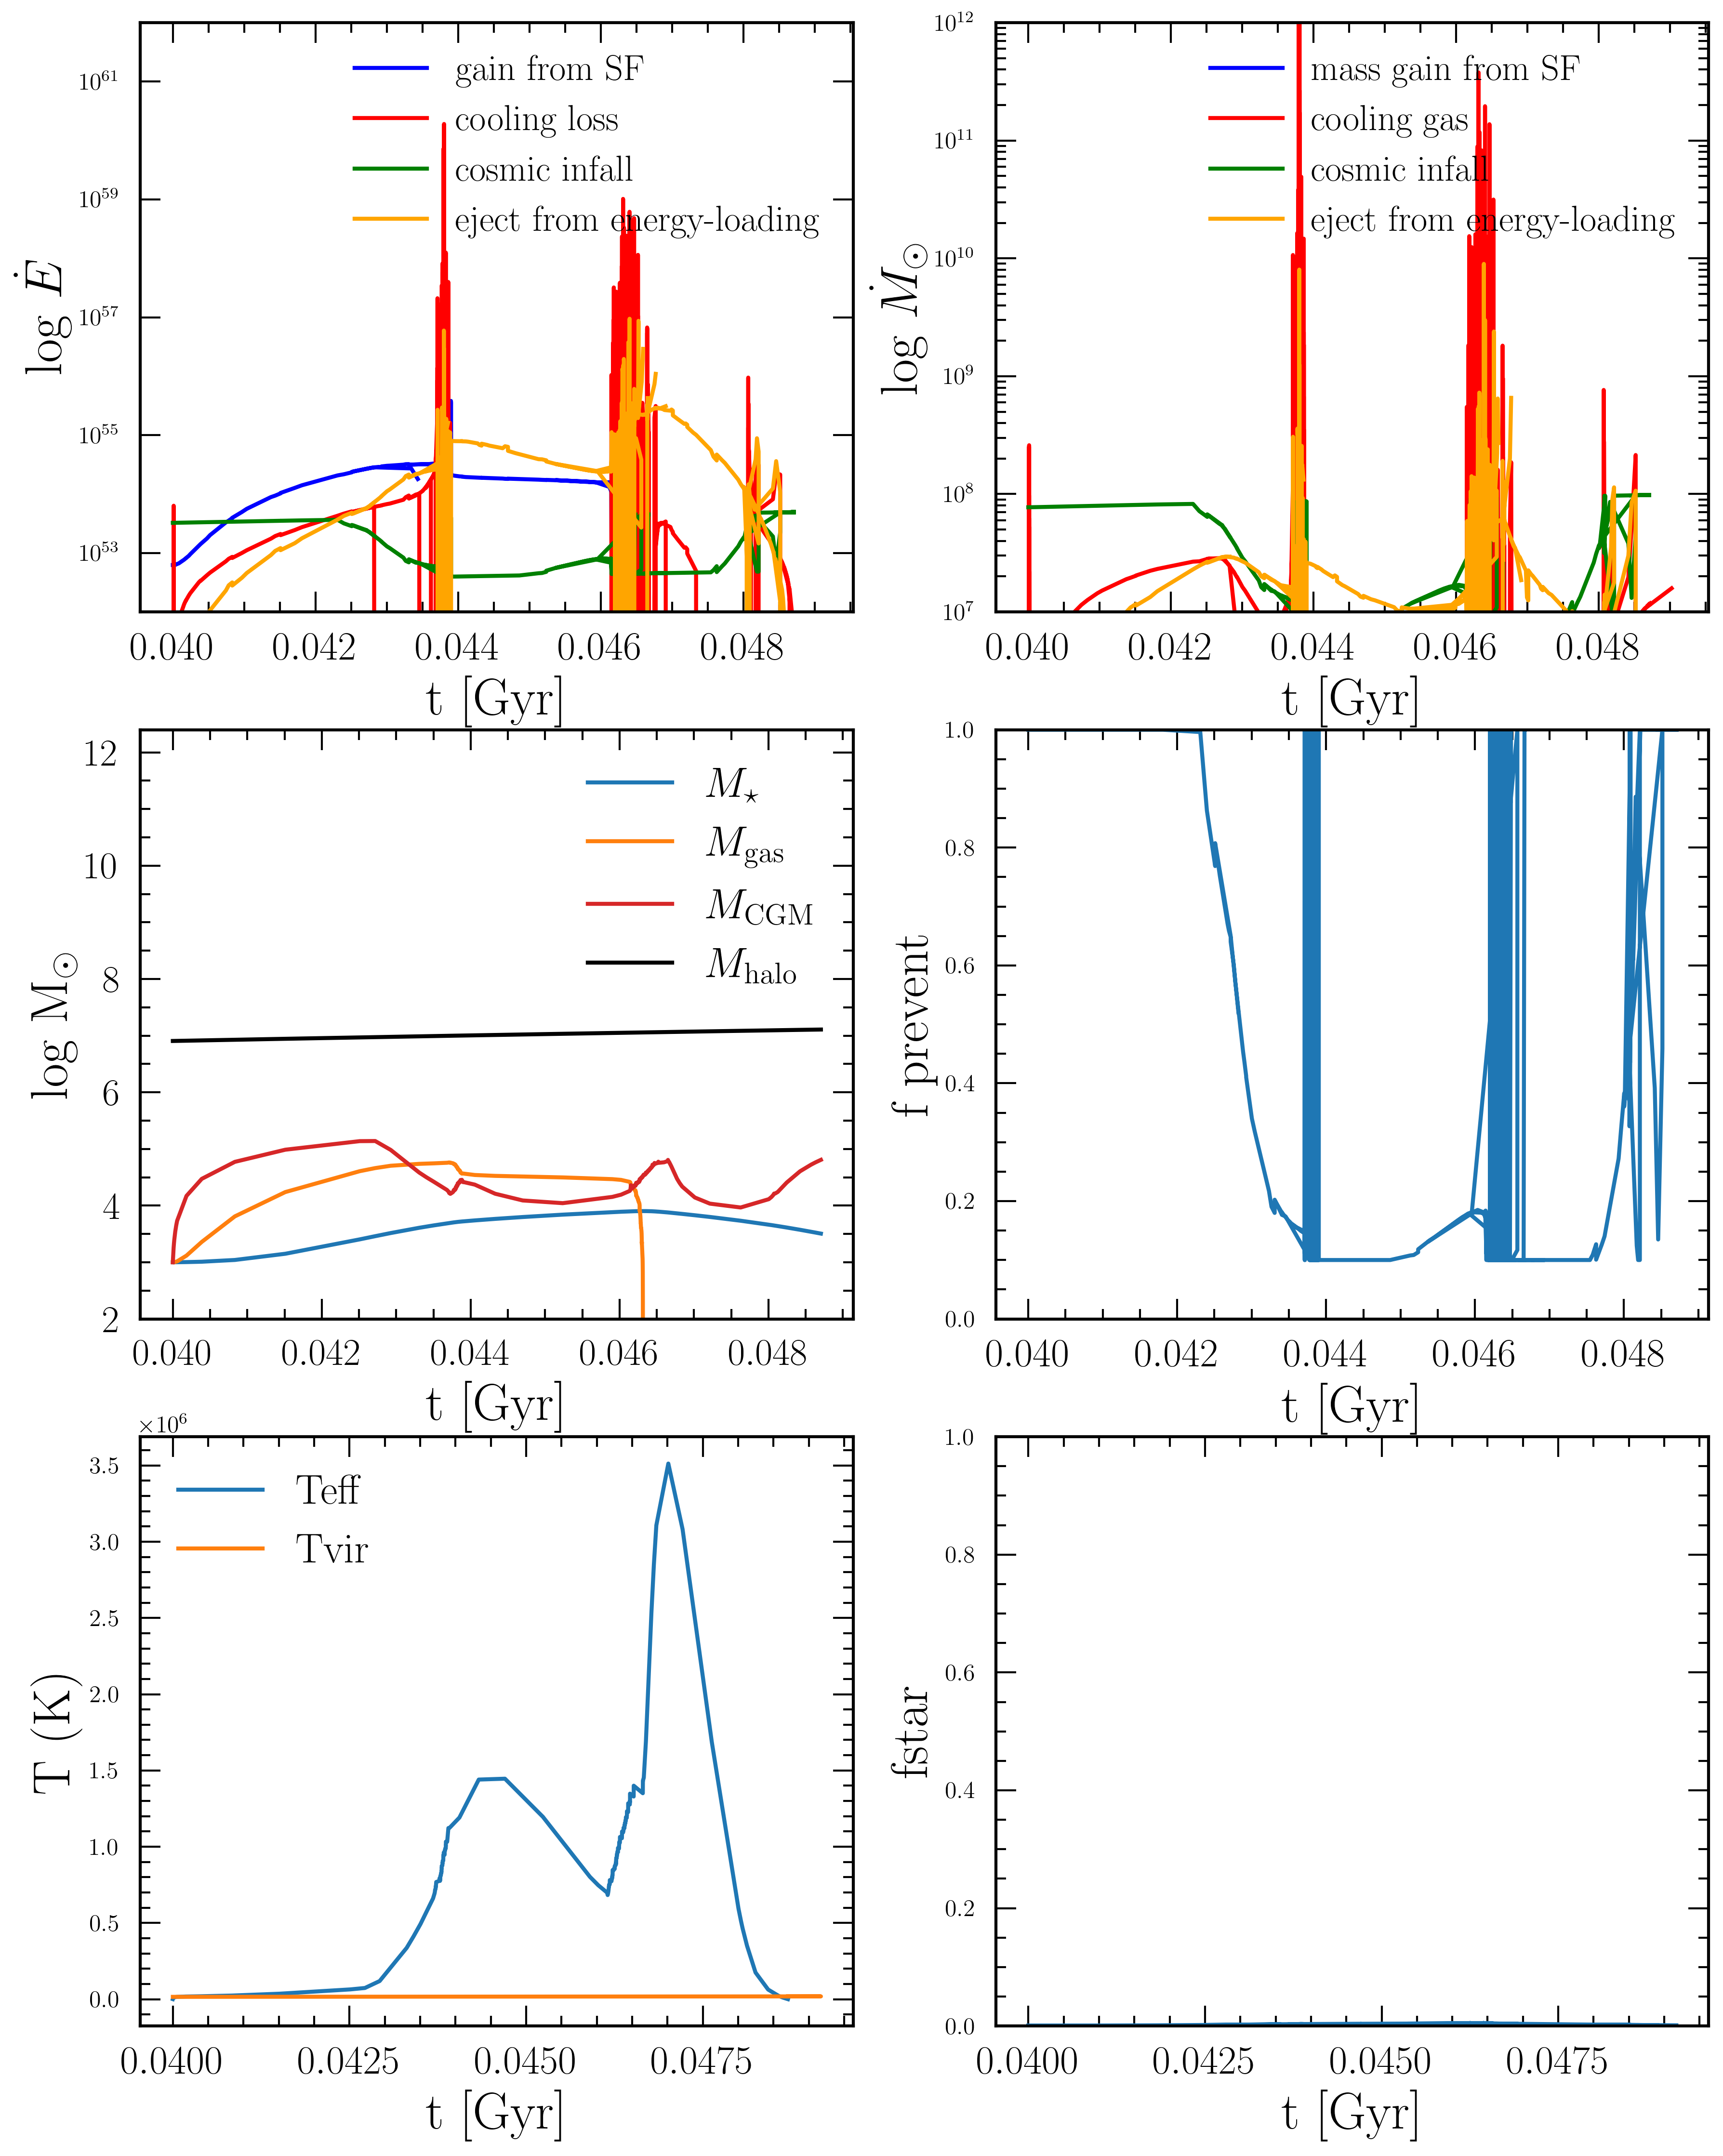

In [ ]:
time_interval = (0.04, 0.5)
explore_halo(1e9 * u.solMass, 0.3, 0.15, time_interval)

z_init, z_final =  29.689787031786974 redshift 0.004812110923745468 redshift


/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


M_halo = 0.0043 x 10^12 Msol
M_star = 0.0052 x 10^10 Msol
f_star = 0.0759
M_gas = 0.0152 x 10^10 Msol
M_CGM = 0.0198 x 10^10 Msol
CGM Z = 0.04


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


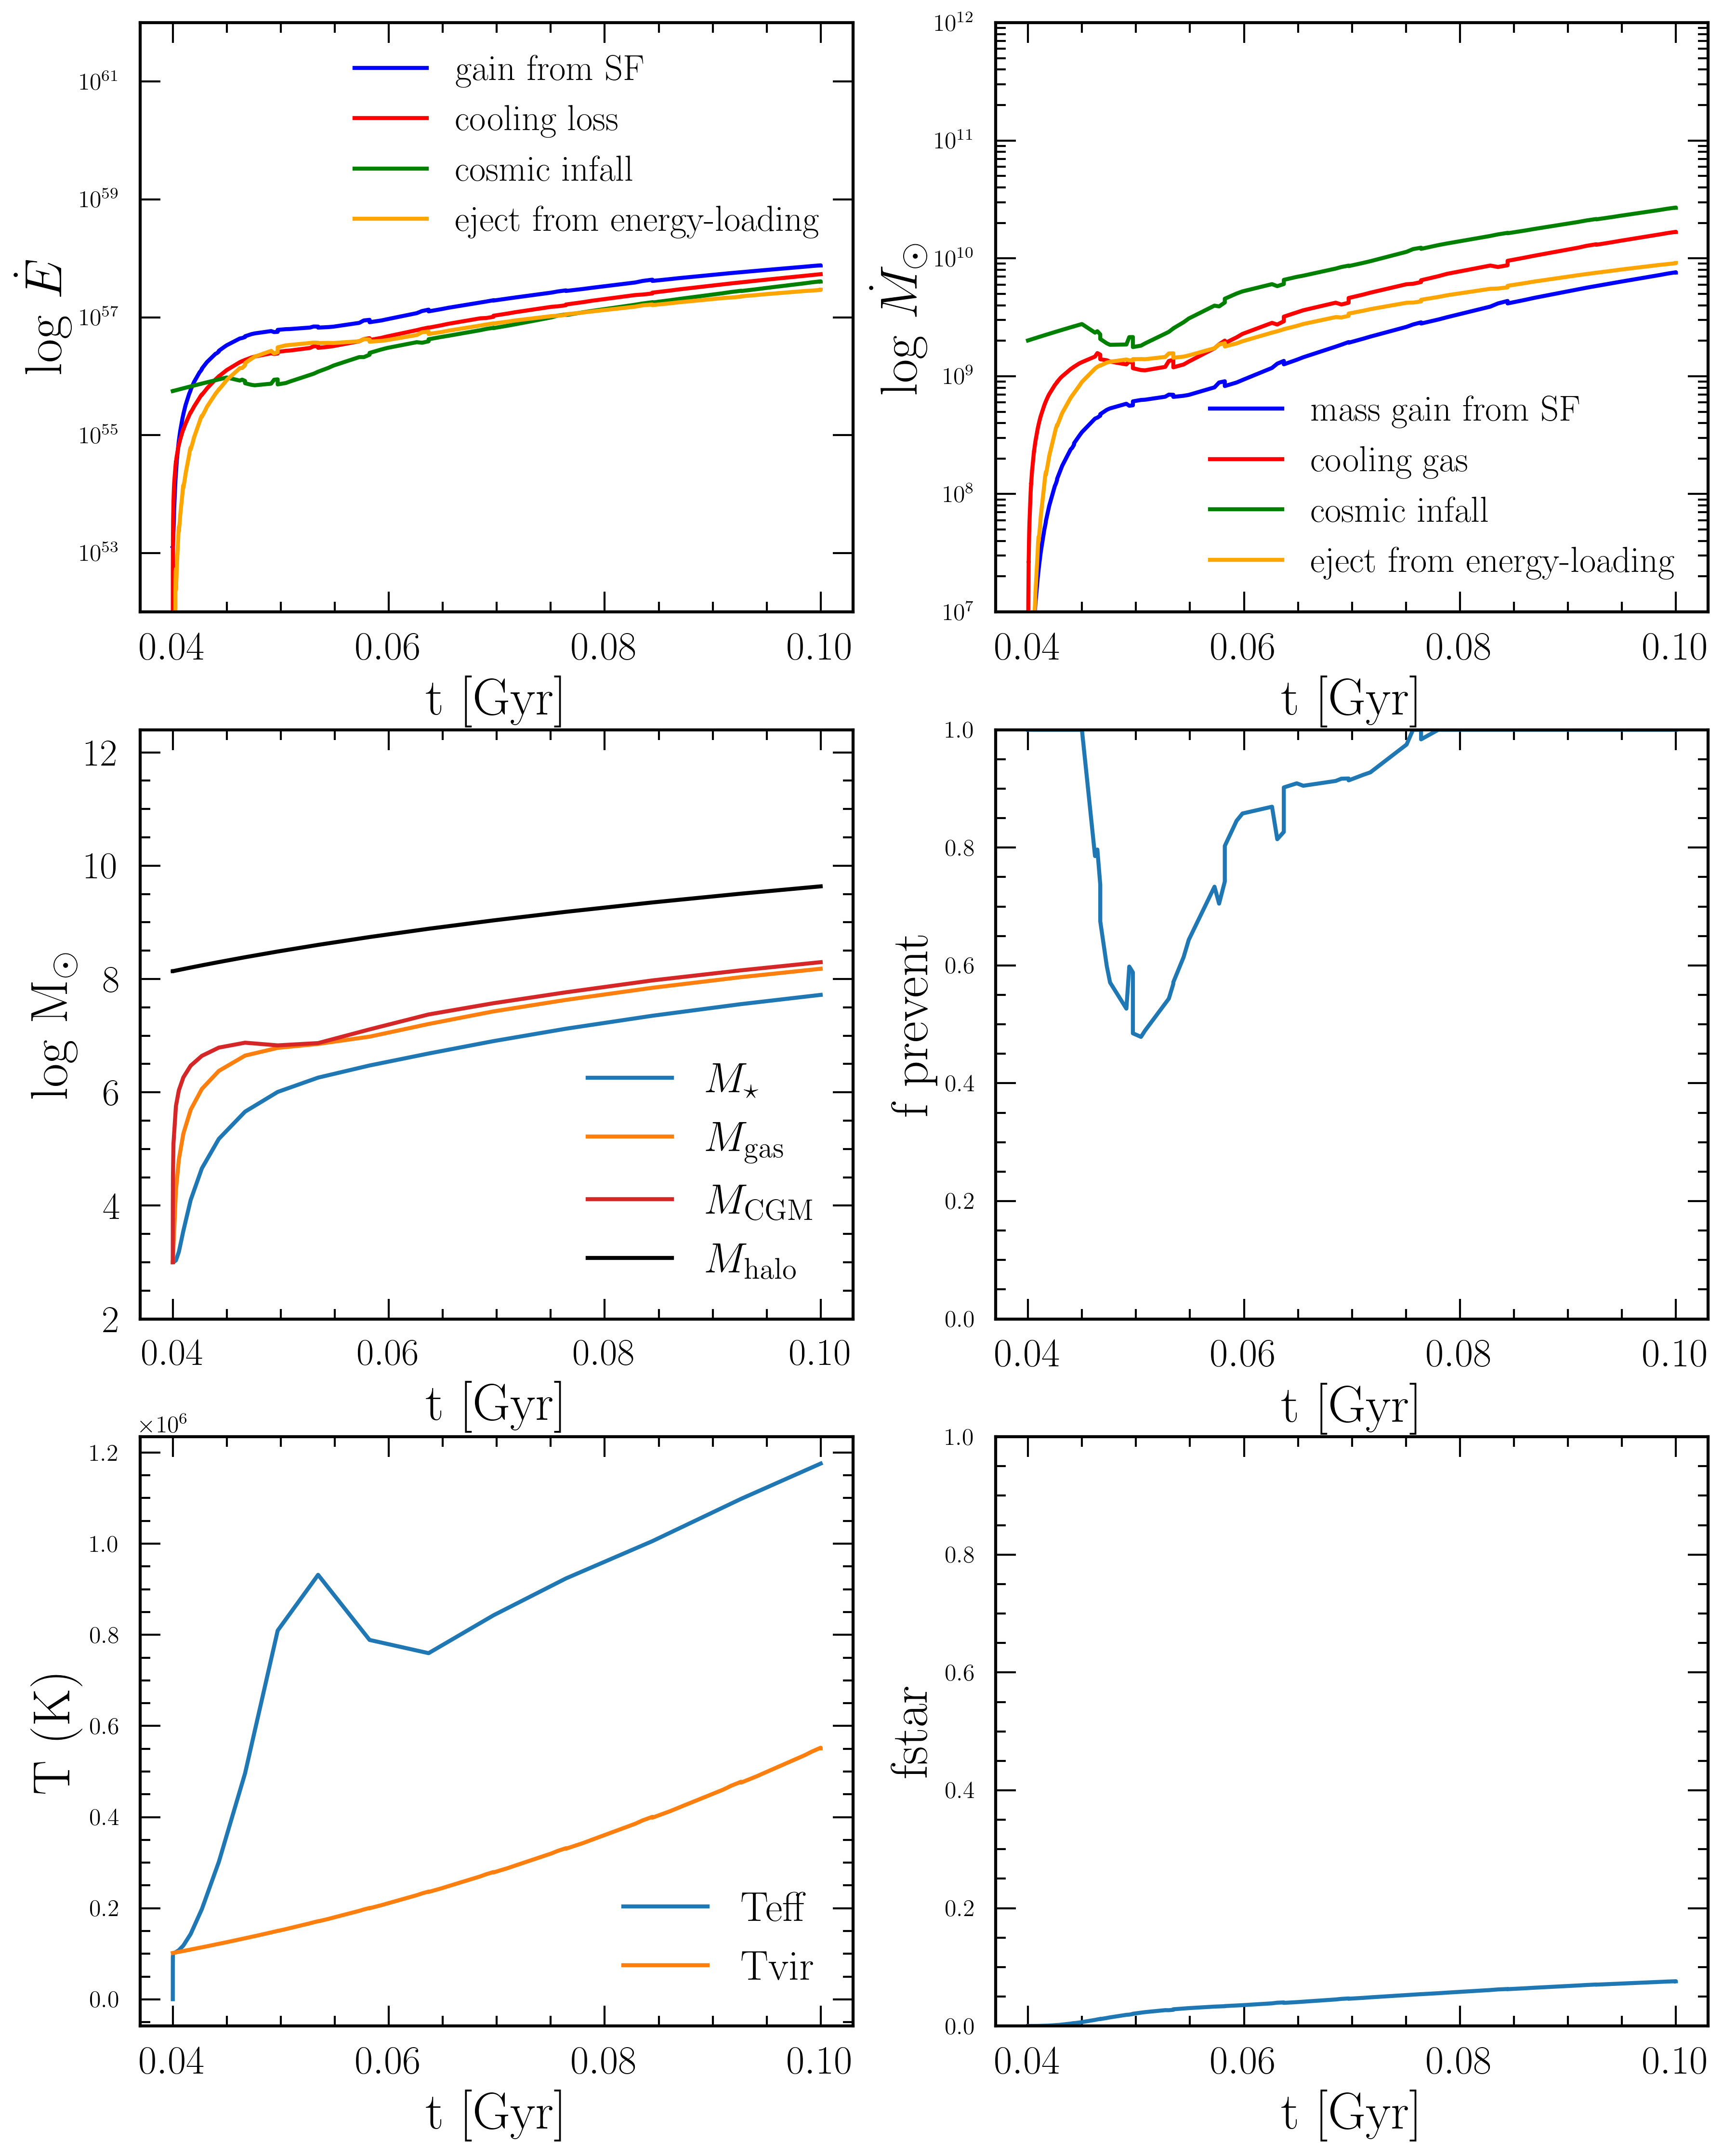

In [ ]:
explore_halo(1e11 * u.solMass, 3, 0.3)

z_init, z_final =  29.689787031786974 redshift 0.004812110923745468 redshift


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


M_halo = 0.0009 x 10^12 Msol
M_star = 0.0003 x 10^10 Msol
f_star = 0.0192
M_gas = 0.0007 x 10^10 Msol
M_CGM = 0.0019 x 10^10 Msol
CGM Z = 0.02


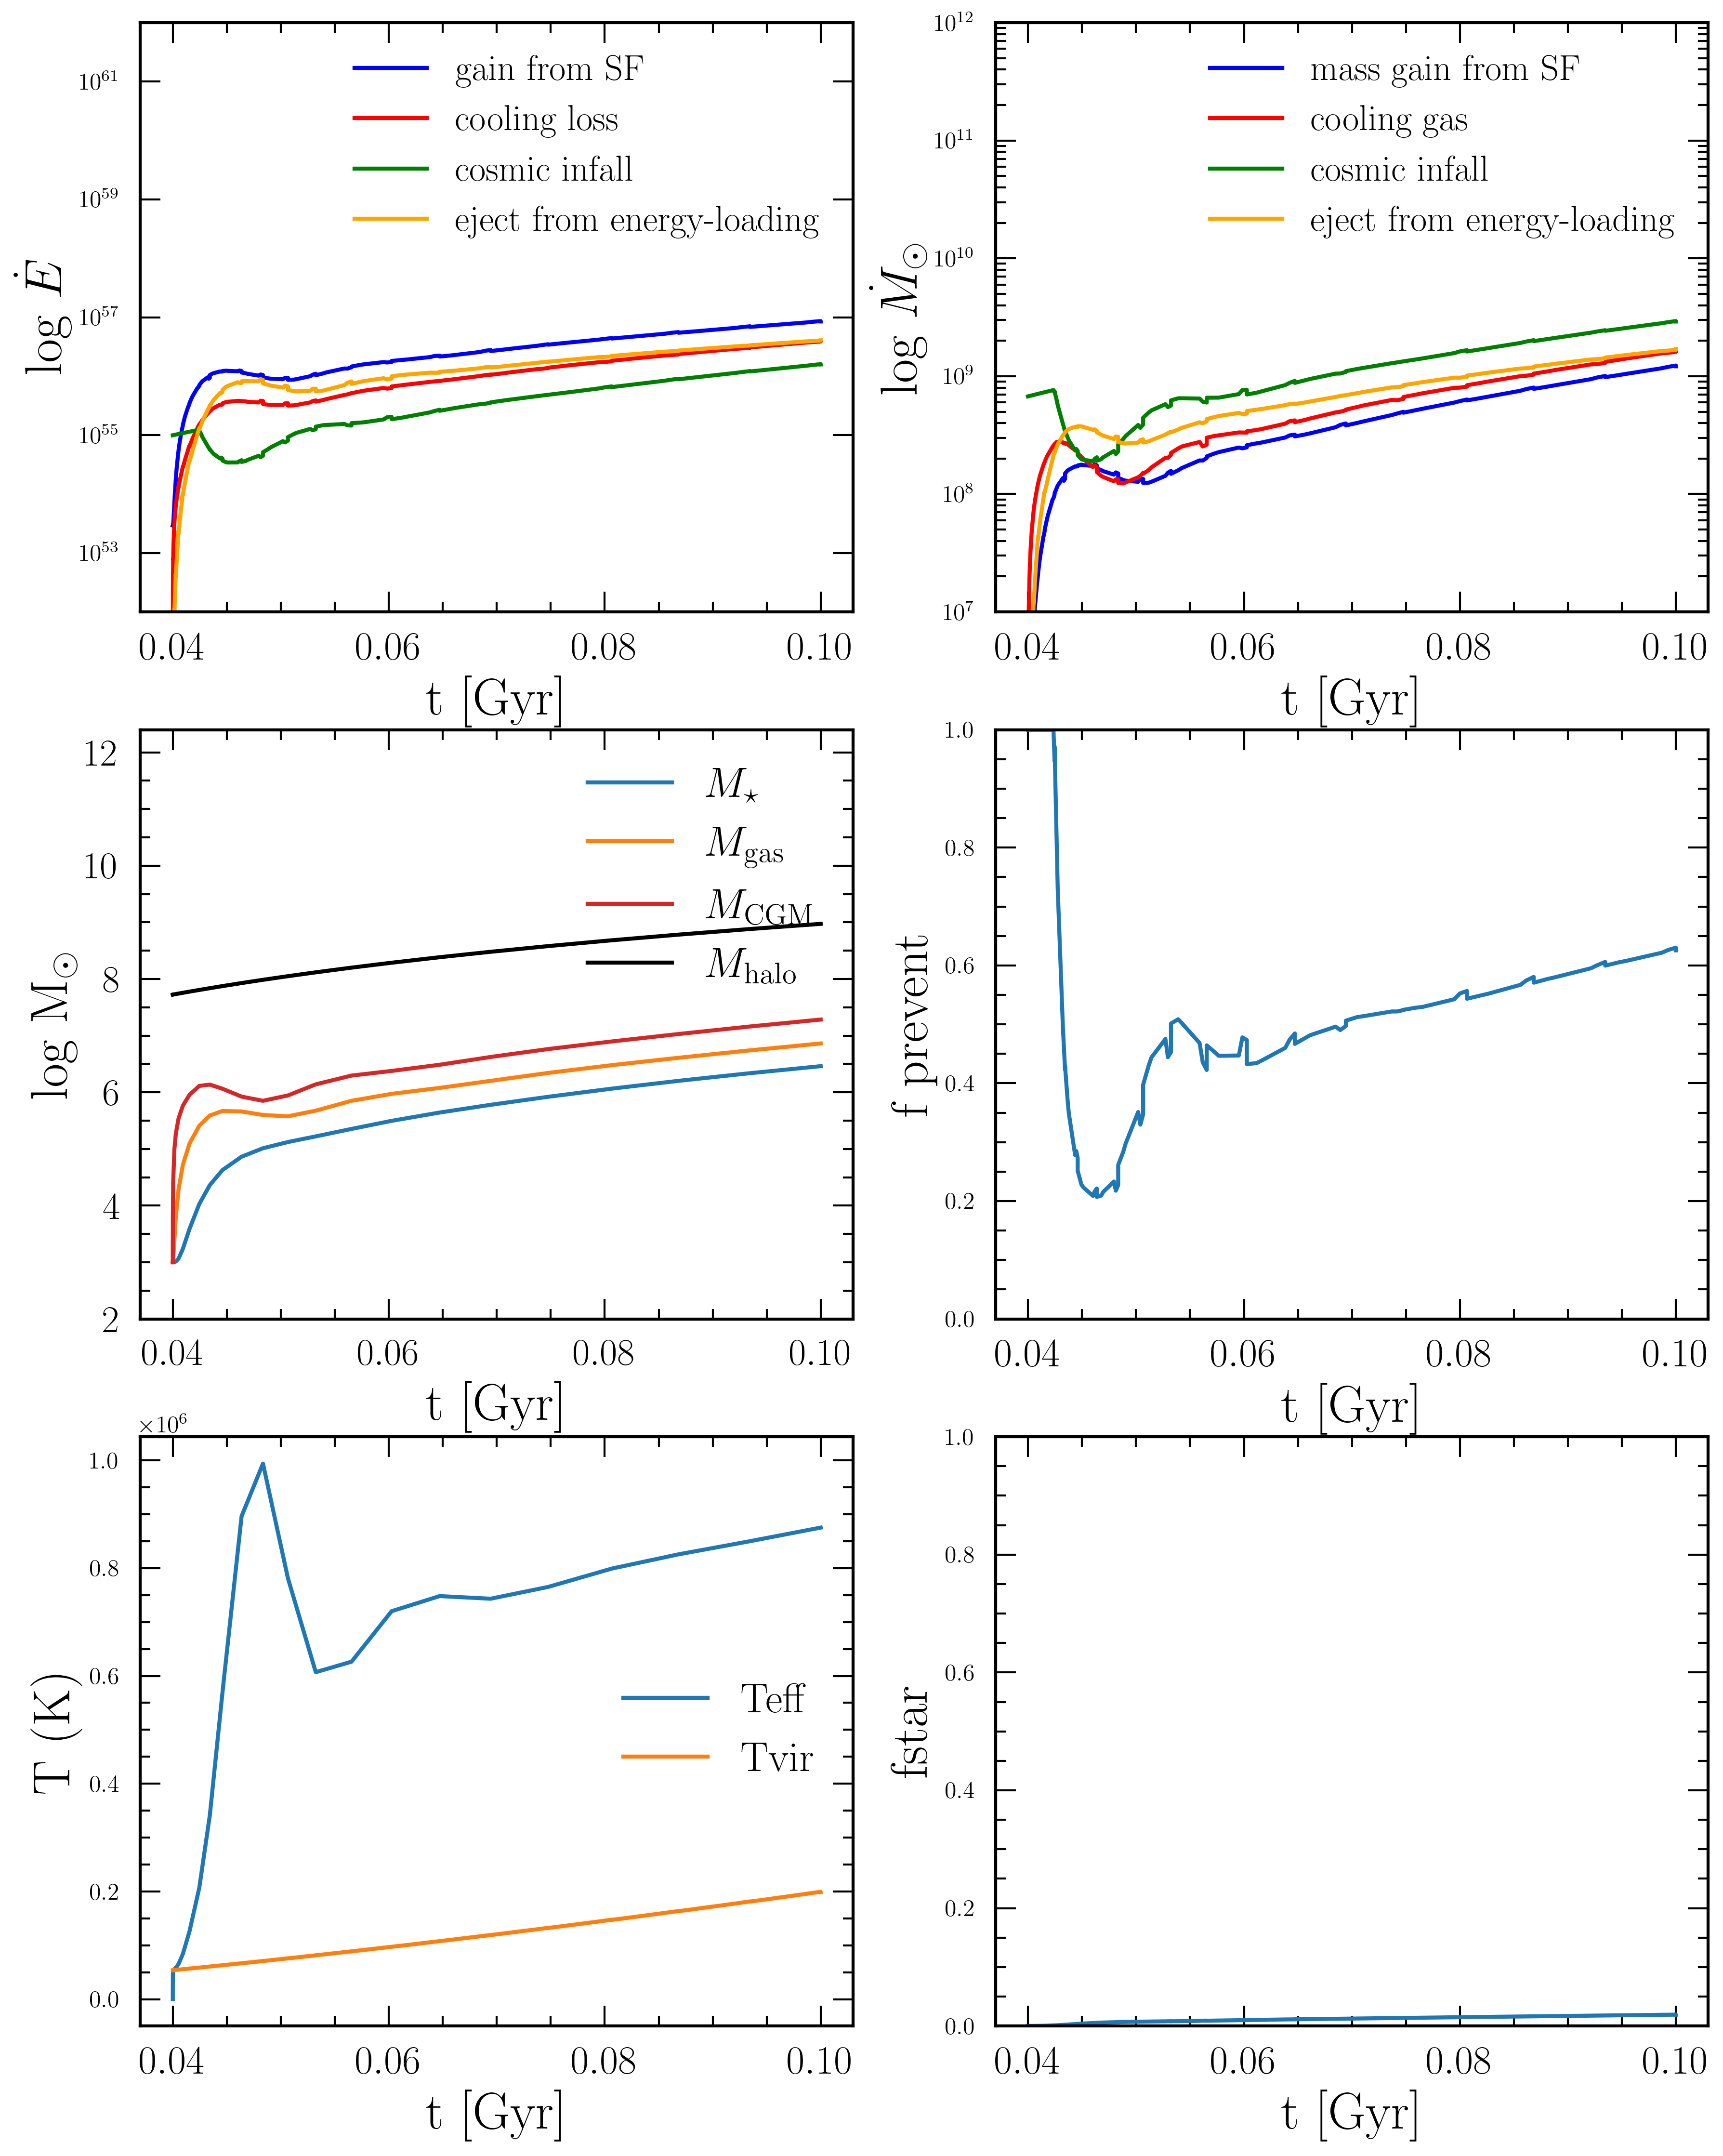

In [ ]:
explore_halo(1e10 * u.solMass, 10, 0.7)

In [ ]:
halo_mass = [
    1e10,
    2.5e10,
    5e10,
    7.5e10,
    1e11,
    2.5e11,
    5e11,
    7.5e11,
    1e12,
    2.5e12,
    5e12,
    7.5e12,
    1e13,
] * u.solMass
time_interval = (0.3, 1)

beta_list = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
eta_e_list = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
eta_z_list = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.0])

colors = sns.color_palette("ch:s=.25,rot=-.25", len(eta_e_list) + 2)

constants = consts.G, consts.k_B, consts.m_p, fb, Delc
exp = 0.3
C = 0.5
gal_params = y, Z_sol, mu, alpha, exp, C

# # # Looping over halo mass
# fig, ax = plt.subplots(1,3, figsize=(20,6), sharey='all', gridspec_kw={'hspace': 0, 'wspace': 0})
# fig1, ax1 = plt.subplots(1,3, figsize=(20,6), sharey='all', gridspec_kw={'hspace': 0, 'wspace': 0})
# fig2, ax2 = plt.subplots(1,3, figsize=(20,6), sharey='all', gridspec_kw={'hspace': 0, 'wspace': 0})
# fig3, ax3 = plt.subplots(2,3, figsize=(20,12), sharex='all', sharey='row', gridspec_kw={'hspace': 0, 'wspace': 0})
# fig4, ax4 = plt.subplots(1,3, figsize=(20,6), sharey='all', gridspec_kw={'hspace': 0, 'wspace': 0})


# j = -1
# for beta in tqdm.tqdm(beta_list):
TT_list = []
mstar_M_list = []
mgas_M_list = []
mCGM_M_list = []
Z_M_list = []
CB_M_list = []
#     j = j + 1

nhalos = hm[:-4].size
print(nhalos)
nlist = eta_e_list.size
mhalo_M = np.zeros([nlist, nhalos])
mstar_M = np.zeros([nlist, nhalos])
mgas_M = np.zeros([nlist, nhalos])
mCGM_M = np.zeros([nlist, nhalos])
Zcgm_M = np.zeros([nlist, nhalos])
i = 0
for eta_e in eta_e_list:
    j = 0
    for mhalo_z0 in tqdm.tqdm(hm[:-4]):
        # mhalo_z0 = halo_mass[i]
        eta_m = 20 * (mhalo_z0 / (1e10 * u.solMass)) ** -0.7
        eta_z = 0.3
        # eta_e = etaE_spline(np.log10(mhalo_z0.value))
        #        eta_e = 0.1*(mhalo_z0/(1e12*u.solMass))**-0.5
        #        eta_e = 1
        #        print(mhalo_z0, eta_m, eta_e)
        wind_params = eta_m, eta_e, eta_z
        CB_50 = []
        t, z, mgas_t, mstar_t, mCGM_t, mhalo_t, Z, Eg_t, El_t, Eej_t, Eacc_t, E_CGM = (
            bathtub(time_interval, mhalo_z0)
        )

        # mstar_M_list.append(mstar_t[-1])
        # mgas_M_list.append(mgas_t[-1])
        # mCGM_M_list.append(mCGM_t[-1])
        # Z_M_list.append(Z[-1])
        # CB_M_list.append(CB_50[-1])
        # fill in the array, in each row we have the values for a given eta_e
        # for each column we have the values for a given halo mass
        mhalo_M[i, j] = mhalo_z0.value
        mstar_M[i, j] = mstar_t[-1]
        mgas_M[i, j] = mgas_t[-1]
        mCGM_M[i, j] = mCGM_t[-1]
        Zcgm_M[i, j] = Z[-1]
        j = j + 1
    i = i + 1
# CB_M = np.array(CB_M_list)

# print(AA)
AA = np.vstack((mstar_M, mgas_M, mCGM_M, Zcgm_M))

# with open("low_etaM_"+str(beta)+".pkl", mode="wb") as f:
#     pickle.dump(AA, f)

with open("etaM_1-BS-05loss.pkl", mode="wb") as f:
    pickle.dump(mstar_M, f)

9


100%|██████████| 9/9 [00:10<00:00,  1.17s/it]


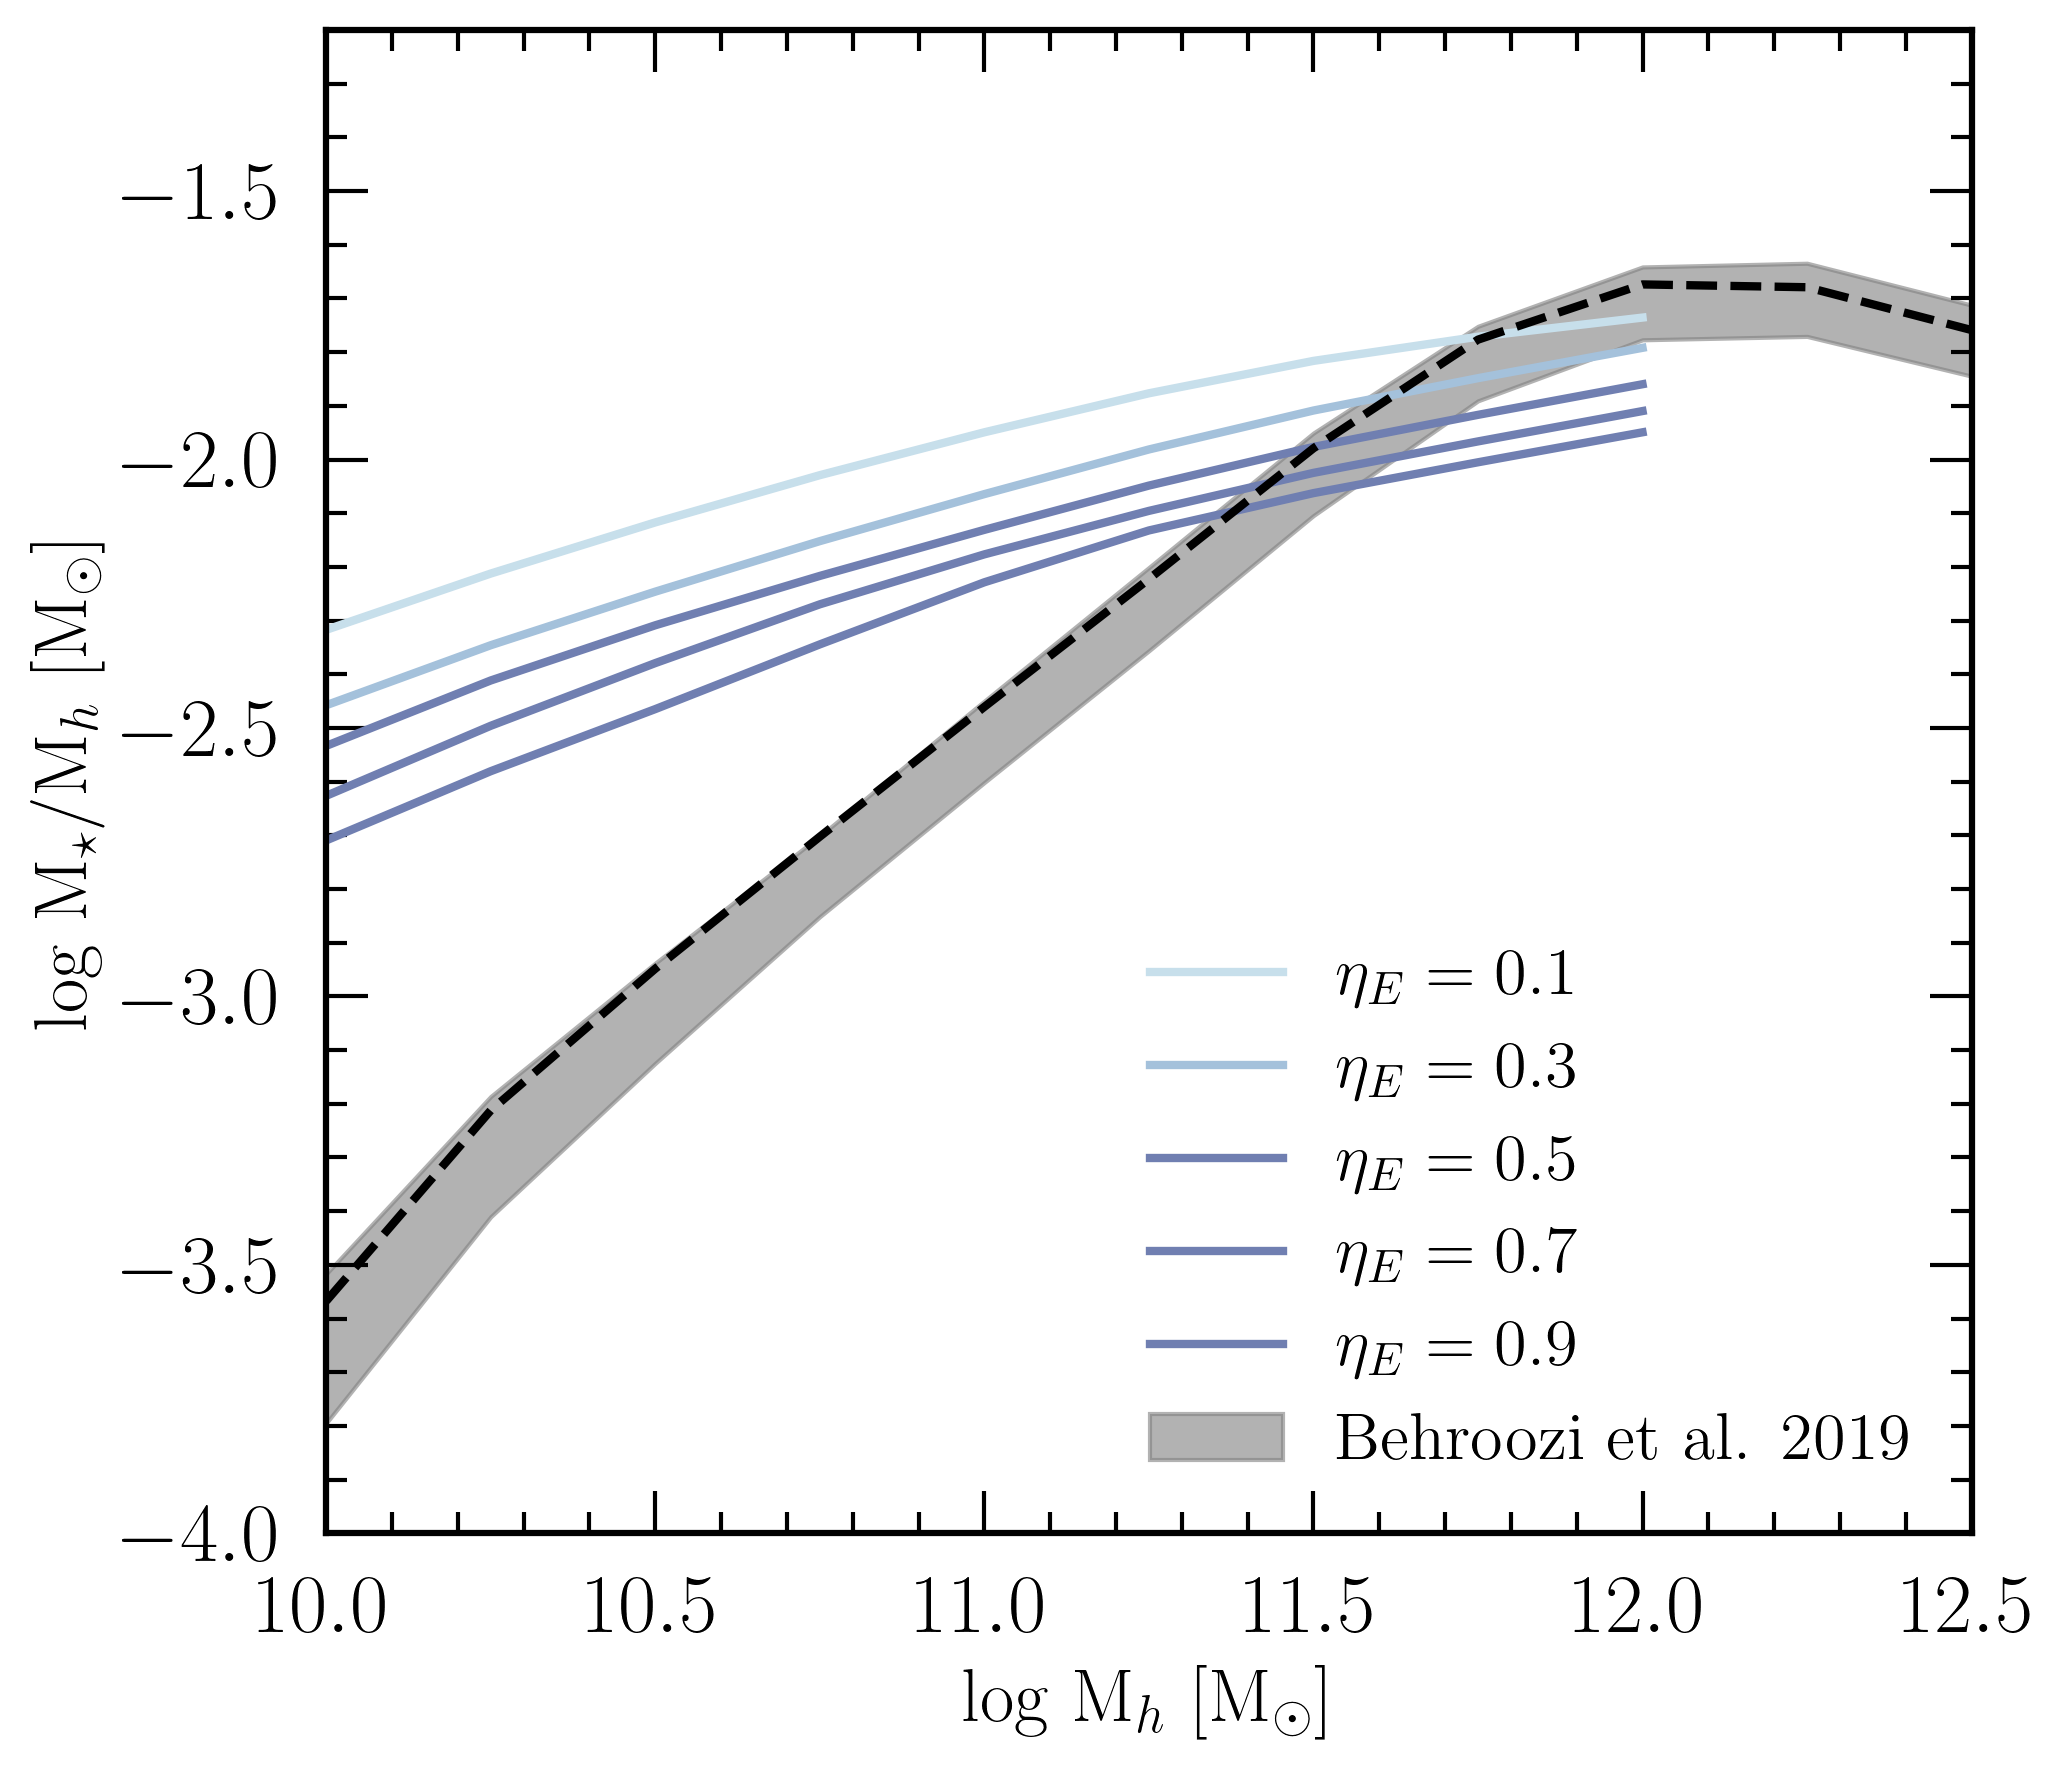

In [ ]:
# print(hm)
# print(AA)
# with open("etaM_1-BS-05loss.pkl", mode="rb") as f:
#    Ma = pickle.load(f)
# mstar_M, mgas_M, mCGM_M, Zcgm_M = Ma[:,:]


fig, ax = plt.subplots(1, 1, figsize=(7, 6), sharey="all")

# ax.annotate(r'$\eta_m$ ='+str(1)+', $\eta_Z$ = 0.3',
#               xy=(300, 125), xycoords='figure points', fontsize=20)

ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[0, :] / hm[:-4].value),
    color=colors[0],
    label="$\eta_E = 0.1$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[1, :] / hm[:-4].value),
    color=colors[1],
    label="$\eta_E = 0.3$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[2, :] / hm[:-4].value),
    color=colors[3],
    label="$\eta_E = 0.5$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[3, :] / hm[:-4].value),
    color=colors[3],
    label="$\eta_E = 0.7$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[4, :] / hm[:-4].value),
    color=colors[3],
    label="$\eta_E = 0.9$",
)

ax.plot(loghm, logSMHM, color="k", ls="--")
ax.fill_between(
    loghm,
    logSMHM + SMHMerr[1, :],
    logSMHM - SMHMerr[0, :],
    color="gray",
    alpha=0.6,
    label="Behroozi et al. 2019",
)
ax.set_xlabel("log M$_h$ [M$_\odot$]", fontsize=18)
ax.set_ylabel("log M$_\star$/M$_h$ [M$_\odot$]", fontsize=18)

ax.set_xlim(10, 12.5)
ax.set_ylim(-4, -1.2)
ax.tick_params(labelsize=20)
# ax.set_title('')

# ax.grid()
ax.legend(fontsize=16)
fig.tight_layout()


# fig.savefig('MsMh-RB_low_etaM.jpeg')

In [ ]:
nhalos = hm[:-4].size
print(nhalos)
eta_m_list = np.array([0.3, 1, 3, 10])
nlist = eta_m_list.size
mhalo_M = np.zeros([nlist, nhalos])
mstar_M = np.zeros([nlist, nhalos])
mgas_M = np.zeros([nlist, nhalos])
mCGM_M = np.zeros([nlist, nhalos])
Zcgm_M = np.zeros([nlist, nhalos])
i = 0

for eta_m in eta_m_list:
    j = 0
    for mhalo_z0 in tqdm.tqdm(hm[:-4]):
        # mhalo_z0 = halo_mass[i]
        #        eta_m = 20*(mhalo_z0/(1e10*u.solMass))**-0.7
        eta_z = 0.3
        # eta_e = etaE_spline(np.log10(mhalo_z0.value))
        #        eta_e = 0.1*(mhalo_z0/(1e12*u.solMass))**-0.5
        eta_e = 0.2
        #        print(mhalo_z0, eta_m, eta_e)
        wind_params = eta_m, eta_e, eta_z
        CB_50 = []
        t, z, mgas_t, mstar_t, mCGM_t, mhalo_t, Z, Eg_t, El_t, Eej_t, Eacc_t, E_CGM = (
            bathtub(time_interval, mhalo_z0)
        )

        # mstar_M_list.append(mstar_t[-1])
        # mgas_M_list.append(mgas_t[-1])
        # mCGM_M_list.append(mCGM_t[-1])
        # Z_M_list.append(Z[-1])
        # CB_M_list.append(CB_50[-1])

        mhalo_M[i, j] = mhalo_z0.value
        mstar_M[i, j] = mstar_t[-1]
        mgas_M[i, j] = mgas_t[-1]
        mCGM_M[i, j] = mCGM_t[-1]
        Zcgm_M[i, j] = Z[-1]
        j = j + 1
    i = i + 1

9


100%|██████████| 9/9 [00:11<00:00,  1.26s/it]


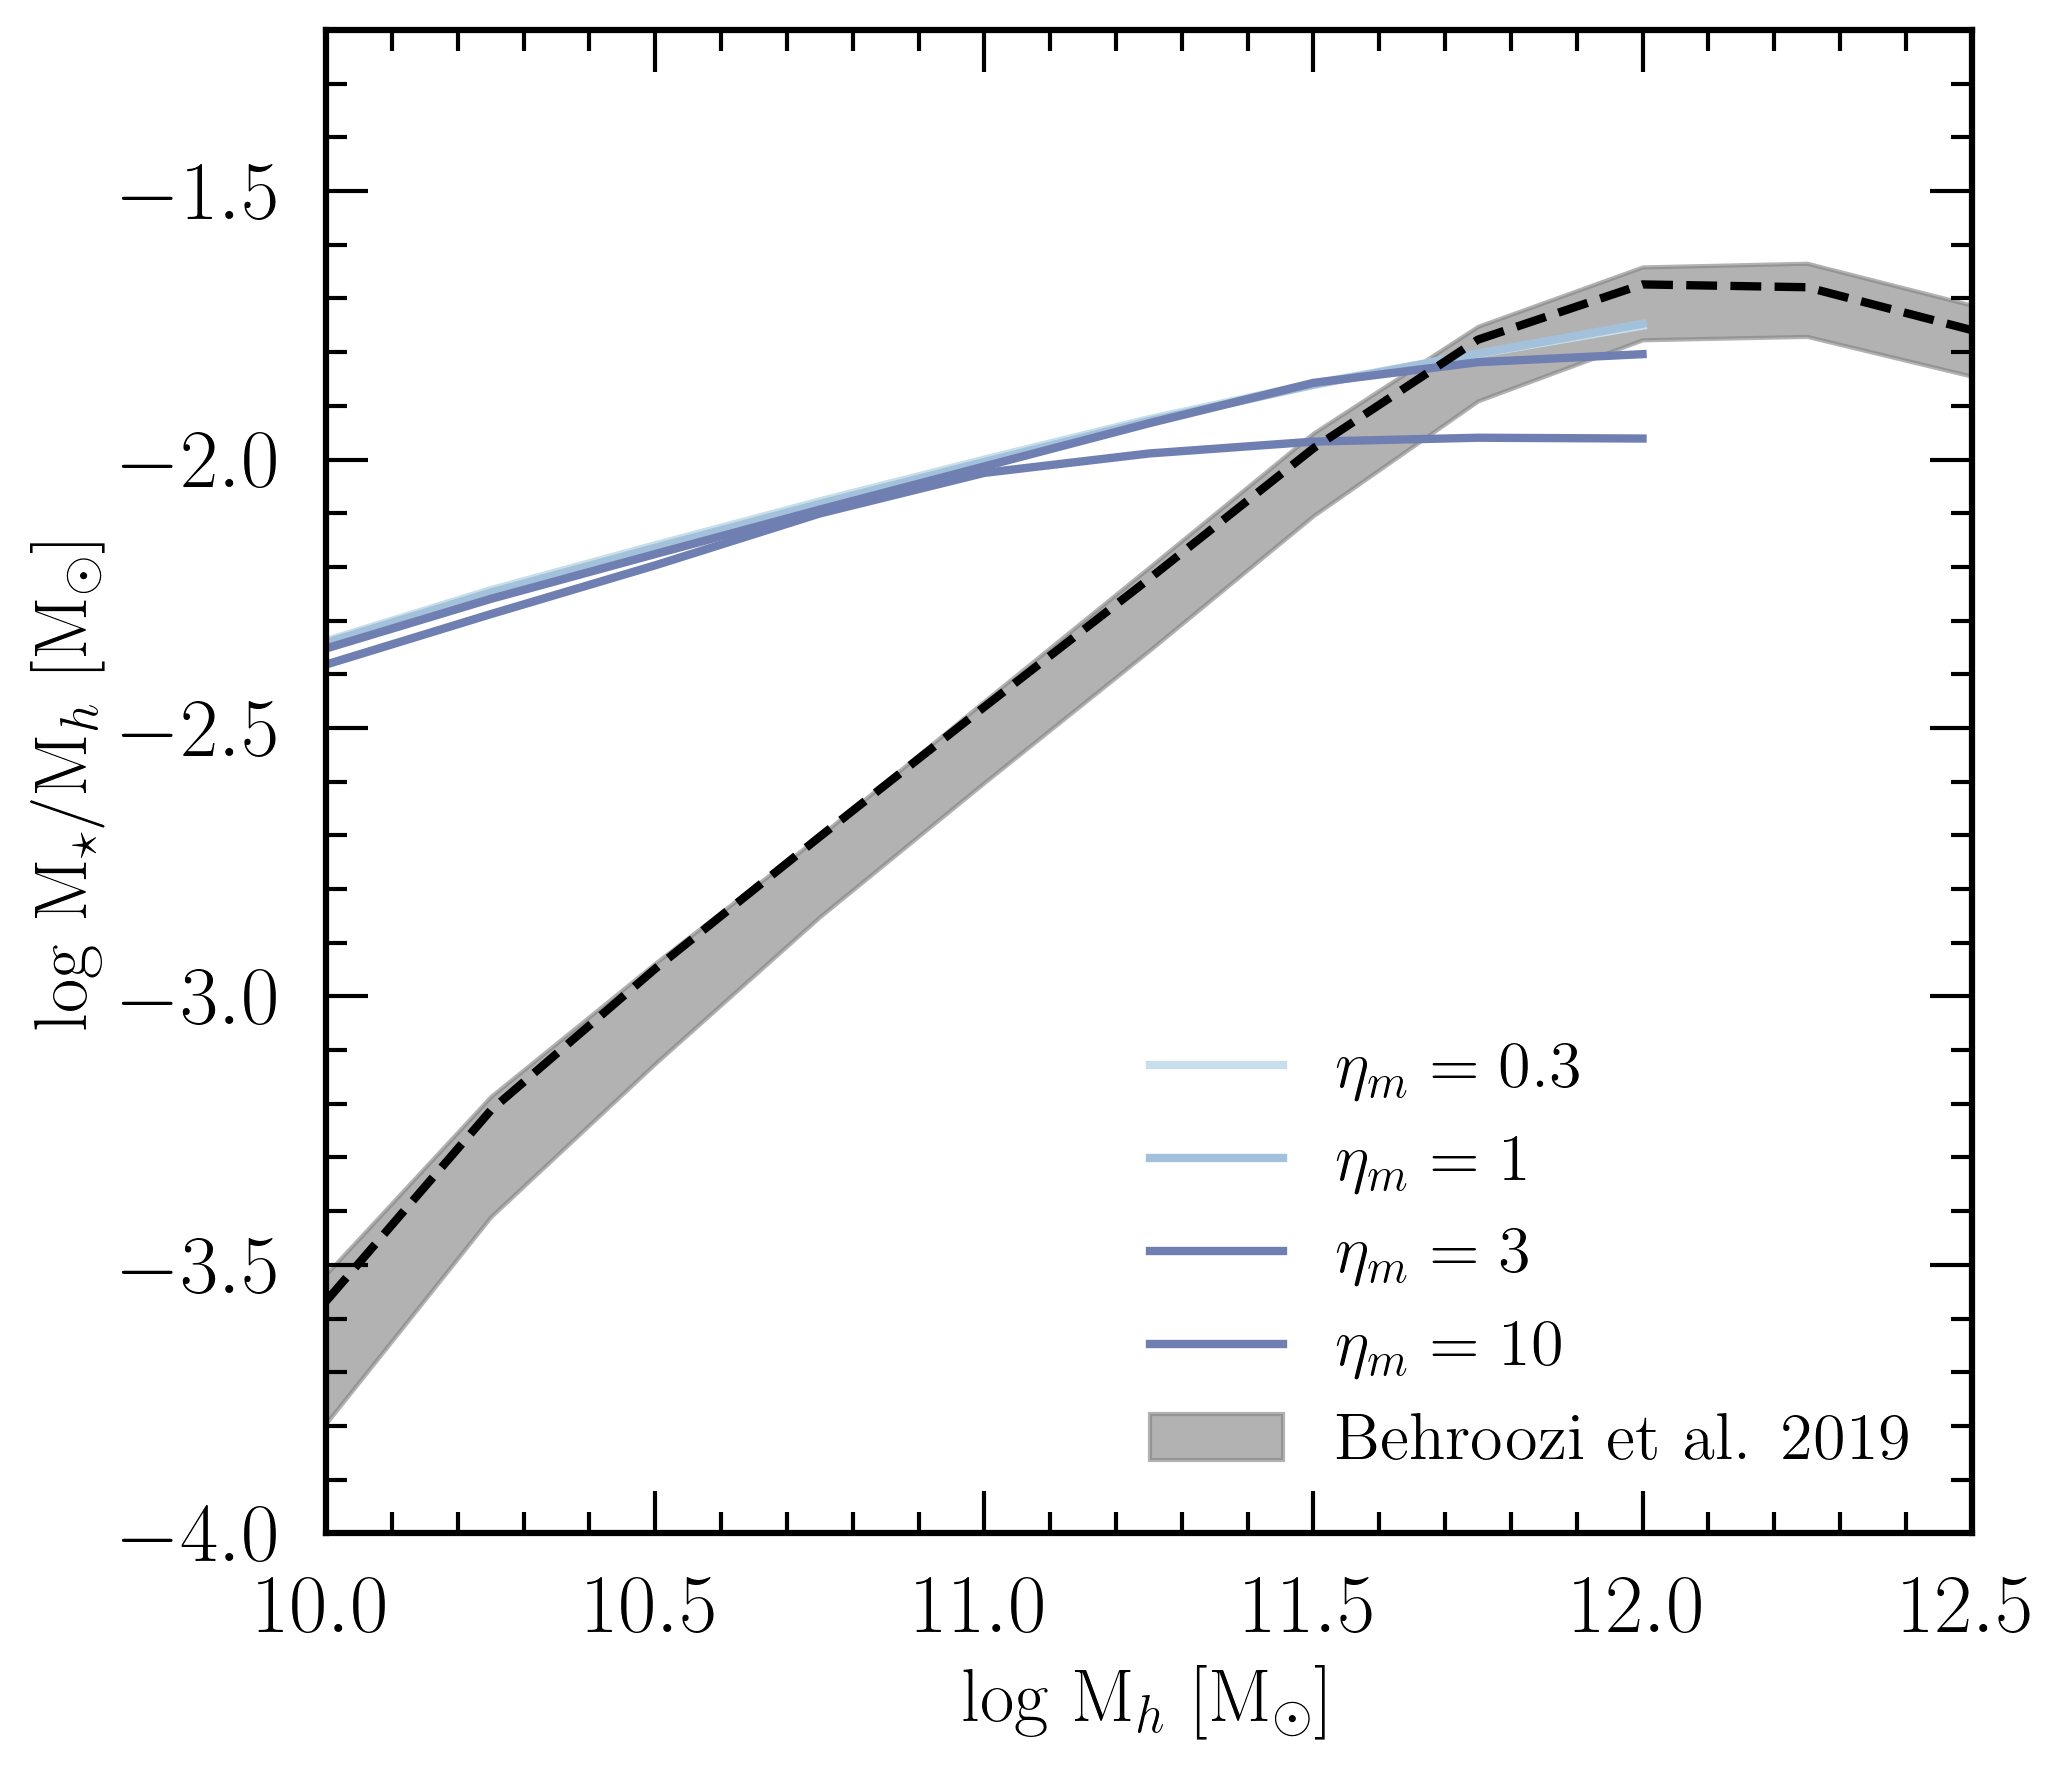

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6), sharey="all")

# ax.annotate(r'$\eta_m$ ='+str(1)+', $\eta_Z$ = 0.3',
#               xy=(300, 125), xycoords='figure points', fontsize=20)

ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[0, :] / hm[:-4].value),
    color=colors[0],
    label="$\eta_m = 0.3$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[1, :] / hm[:-4].value),
    color=colors[1],
    label="$\eta_m = 1$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[2, :] / hm[:-4].value),
    color=colors[3],
    label="$\eta_m = 3$",
)
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M[3, :] / hm[:-4].value),
    color=colors[3],
    label="$\eta_m = 10$",
)


ax.plot(loghm, logSMHM, color="k", ls="--")
ax.fill_between(
    loghm,
    logSMHM + SMHMerr[1, :],
    logSMHM - SMHMerr[0, :],
    color="gray",
    alpha=0.6,
    label="Behroozi et al. 2019",
)
ax.set_xlabel("log M$_h$ [M$_\odot$]", fontsize=18)
ax.set_ylabel("log M$_\star$/M$_h$ [M$_\odot$]", fontsize=18)

ax.set_xlim(10, 12.5)
ax.set_ylim(-4, -1.2)
ax.tick_params(labelsize=20)
# ax.set_title('')

# ax.grid()
ax.legend(fontsize=16)
fig.tight_layout()

In [ ]:
nhalos = hm[:-4].size
print(nhalos)
nlist = 1
mhalo_M3 = np.zeros([nlist, nhalos])
mstar_M3 = np.zeros([nlist, nhalos])
mgas_M3 = np.zeros([nlist, nhalos])
mCGM_M3 = np.zeros([nlist, nhalos])
Zcgm_M3 = np.zeros([nlist, nhalos])
i = 0

for i in range(1):
    j = 0
    for mhalo_z0 in tqdm.tqdm(hm[:-4]):
        # mhalo_z0 = halo_mass[i]
        #        eta_m = 20*(mhalo_z0/(1e10*u.solMass))**-0.7
        eta_z = 0.3
        # eta_e = etaE_spline(np.log10(mhalo_z0.value))
        #        eta_e = 0.1*(mhalo_z0/(1e12*u.solMass))**-0.5
        eta_e = 0.0001
        eta_m = 1
        #        print(mhalo_z0, eta_m, eta_e)
        wind_params = eta_m, eta_e, eta_z
        CB_50 = []
        t, z, mgas_t, mstar_t, mCGM_t, mhalo_t, Z, Eg_t, El_t, Eej_t, Eacc_t, E_CGM = (
            bathtub(time_interval, mhalo_z0)
        )

        # mstar_M_list.append(mstar_t[-1])
        # mgas_M_list.append(mgas_t[-1])
        # mCGM_M_list.append(mCGM_t[-1])
        # Z_M_list.append(Z[-1])
        # CB_M_list.append(CB_50[-1])

        mhalo_M3[i, j] = mhalo_z0.value
        mstar_M3[i, j] = mstar_t[-1]
        mgas_M3[i, j] = mgas_t[-1]
        mCGM_M3[i, j] = mCGM_t[-1]
        Zcgm_M3[i, j] = Z[-1]
        j = j + 1

9


100%|██████████| 9/9 [00:09<00:00,  1.11s/it]


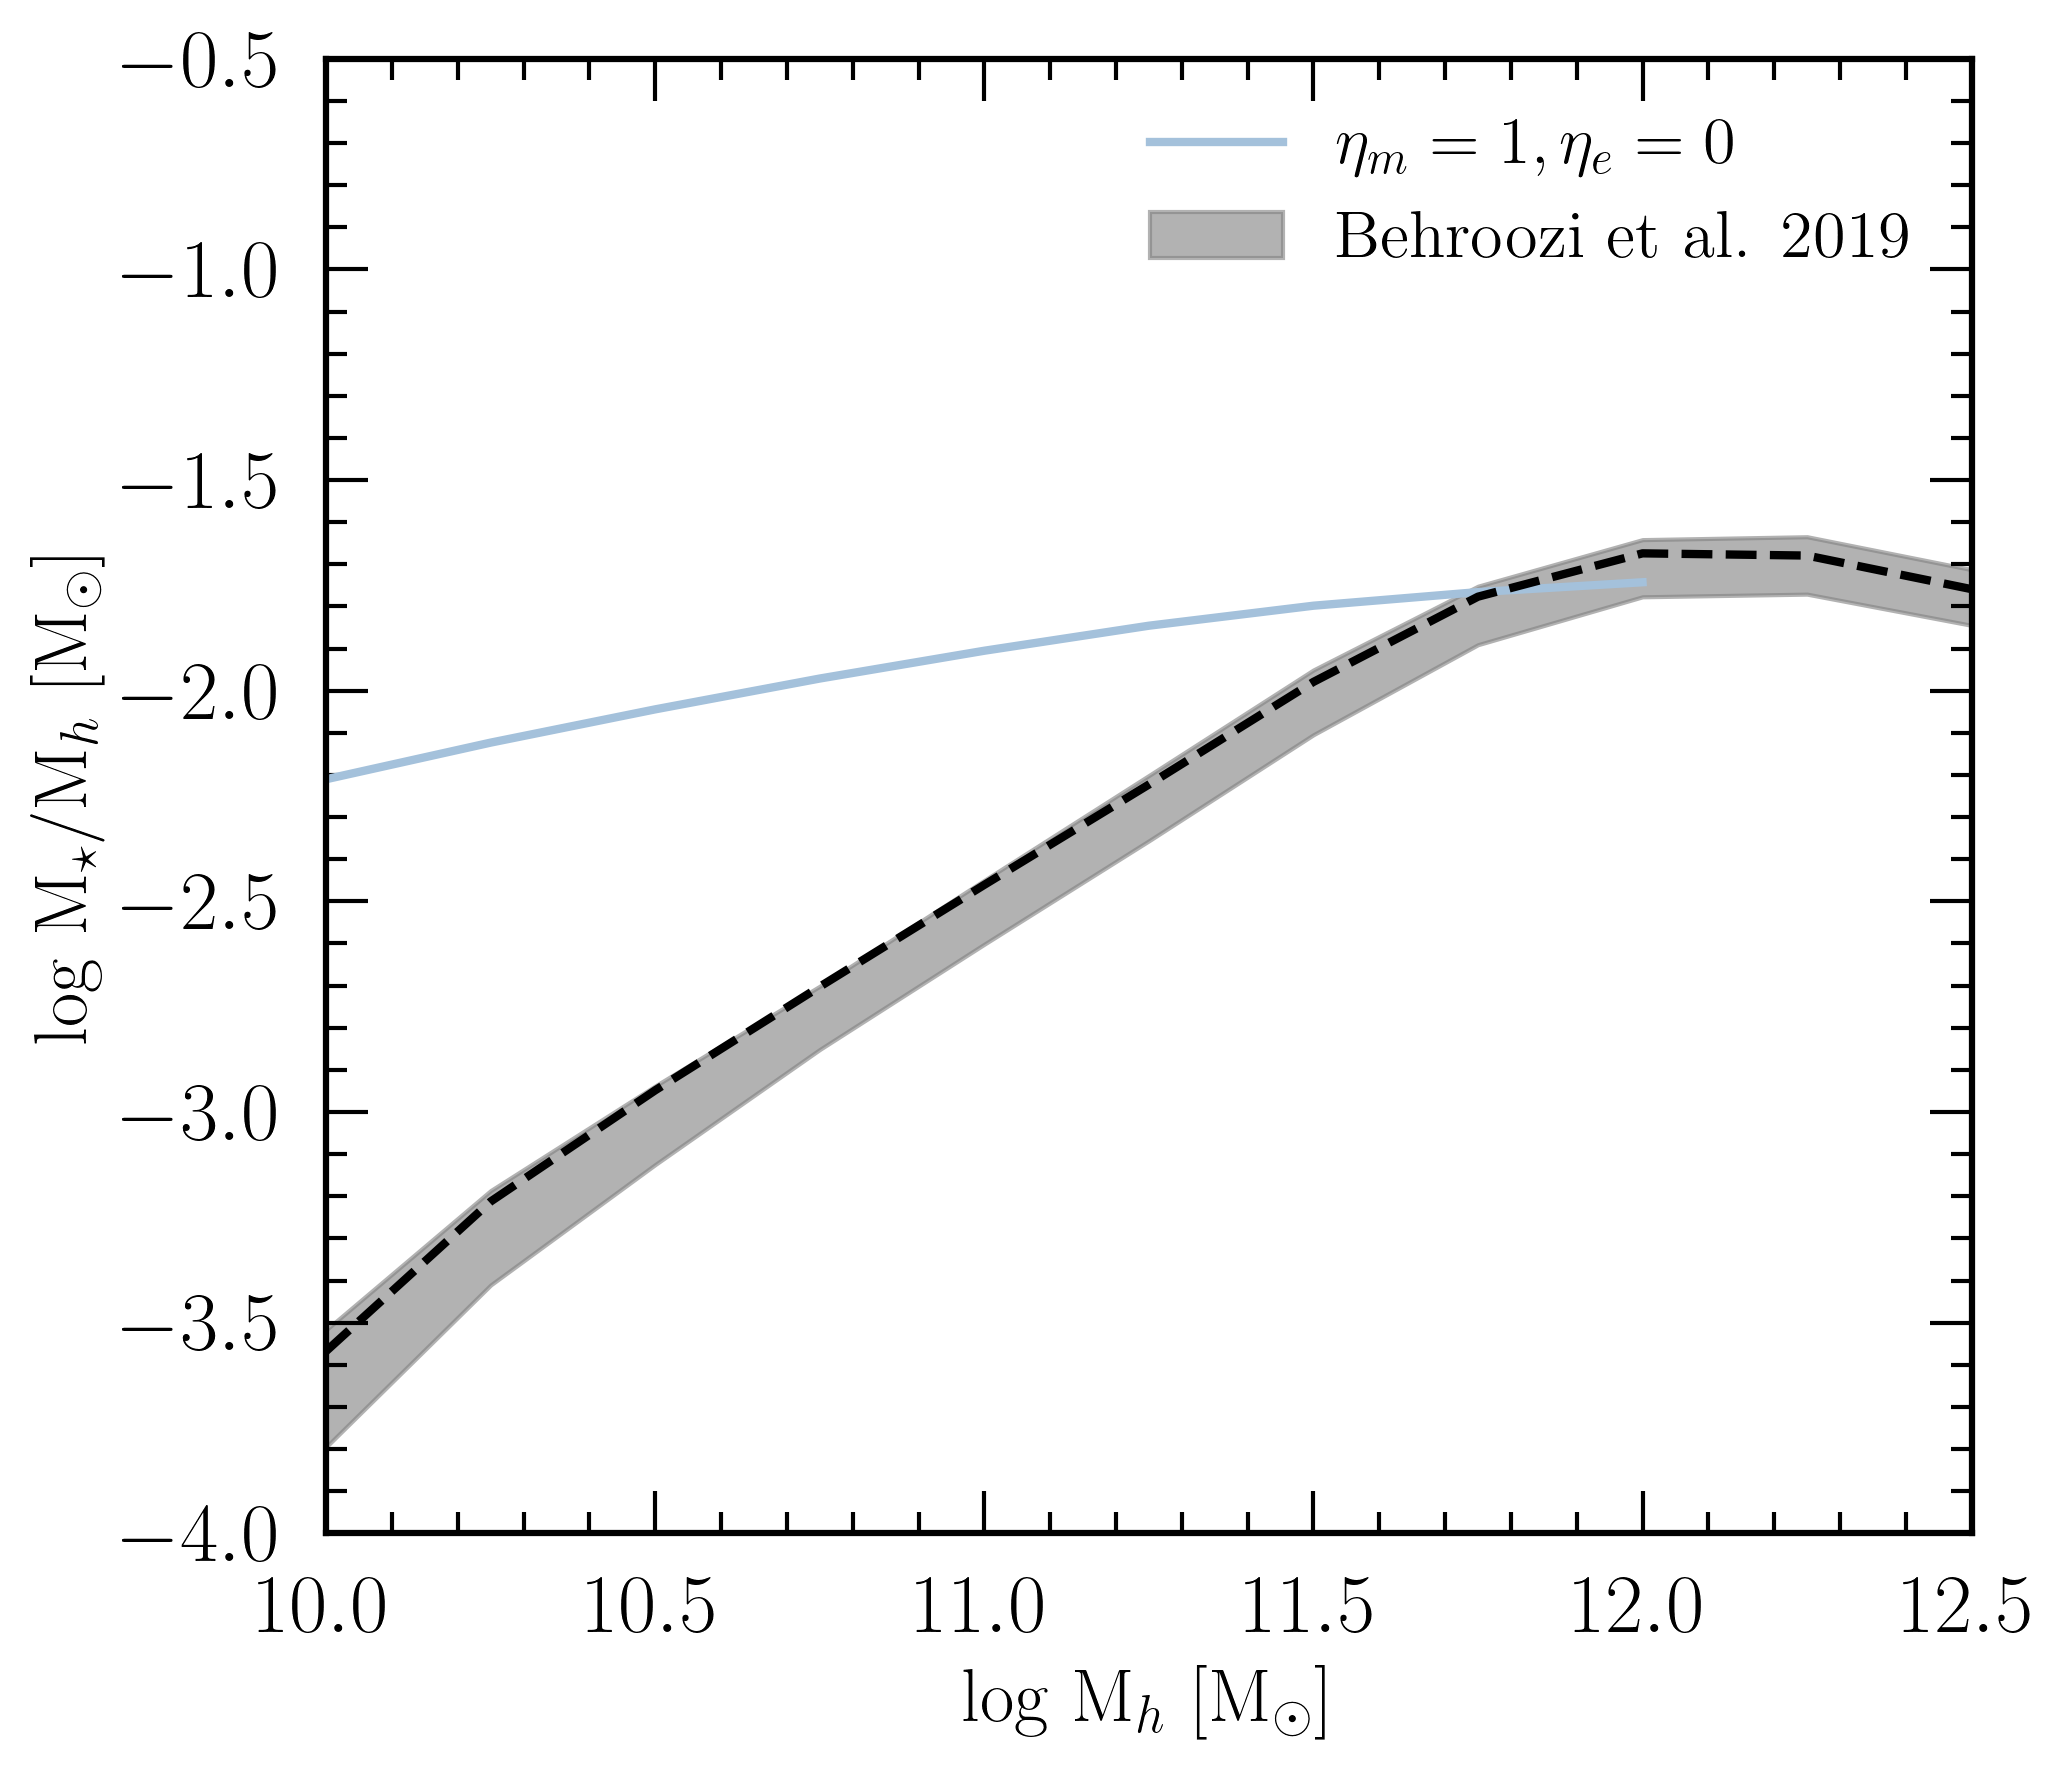

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6), sharey="all")

# ax.annotate(r'$\eta_m$ ='+str(1)+', $\eta_Z$ = 0.3',
#               xy=(300, 125), xycoords='figure points', fontsize=20)

# ax.plot(np.log10(hm[:-4].value), np.log10(0.08*hm[:-4].value/hm[:-4].value) ,color=colors[4],label='$\eta_{M,E} = 0$')
ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M3[0, :] / hm[:-4].value),
    color=colors[1],
    label="$\eta_m = 1, \eta_e = 0$",
)
# ax.plot(np.log10(hm[:-4].value), np.log10(mstar_M[2,:]/hm[:-4].value) ,color=colors[3],label='$\eta_m = 3$')
# ax.plot(np.log10(hm[:-4].value), np.log10(mstar_M[3,:]/hm[:-4].value) ,color=colors[3],label='$\eta_m = 10$')


ax.plot(loghm, logSMHM, color="k", ls="--")
ax.fill_between(
    loghm,
    logSMHM + SMHMerr[1, :],
    logSMHM - SMHMerr[0, :],
    color="gray",
    alpha=0.6,
    label="Behroozi et al. 2019",
)
ax.set_xlabel("log M$_h$ [M$_\odot$]", fontsize=18)
ax.set_ylabel("log M$_\star$/M$_h$ [M$_\odot$]", fontsize=18)

ax.set_xlim(10, 12.5)
ax.set_ylim(-4, -0.5)
ax.tick_params(labelsize=20)
# ax.set_title('')

# ax.grid()
ax.legend(fontsize=16)
fig.tight_layout()

In [ ]:
nhalos = hm[:-4].size
time_interval = (0.3, 1)
nlist = 1
mhalo_M4 = np.zeros([nlist, nhalos])
mstar_M4 = np.zeros([nlist, nhalos])
mgas_M4 = np.zeros([nlist, nhalos])
mCGM_M4 = np.zeros([nlist, nhalos])
Zcgm_M4 = np.zeros([nlist, nhalos])
i = 0

for i in range(nlist):
    j = 0
    for mhalo_z0 in tqdm.tqdm(hm[:-4]):
        # mhalo_z0 = halo_mass[i]
        eta_m = 10 * (mhalo_z0 / (1e10 * u.solMass)) ** -0.7
        eta_z = 0.3
        # eta_e = etaE_spline(np.log10(mhalo_z0.value))
        eta_e = 0.15 * (mhalo_z0 / (1e12 * u.solMass)) ** -0.5
        #        print(mhalo_z0, eta_m, eta_e)
        wind_params = eta_m, eta_e, eta_z
        CB_50 = []
        t, z, mgas_t, mstar_t, mCGM_t, mhalo_t, Z, Eg_t, El_t, Eej_t, Eacc_t, E_CGM = (
            bathtub(time_interval, mhalo_z0)
        )

        # mstar_M_list.append(mstar_t[-1])
        # mgas_M_list.append(mgas_t[-1])
        # mCGM_M_list.append(mCGM_t[-1])
        # Z_M_list.append(Z[-1])
        # CB_M_list.append(CB_50[-1])

        mhalo_M4[i, j] = mhalo_z0.value
        mstar_M4[i, j] = mstar_t[-1]
        mgas_M4[i, j] = mgas_t[-1]
        mCGM_M4[i, j] = mCGM_t[-1]
        Zcgm_M4[i, j] = Z[-1]
        j = j + 1

  0%|          | 0/9 [00:00<?, ?it/s]/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
100%|██████████| 9/9 [00:12<00:00,  1.38s/it]


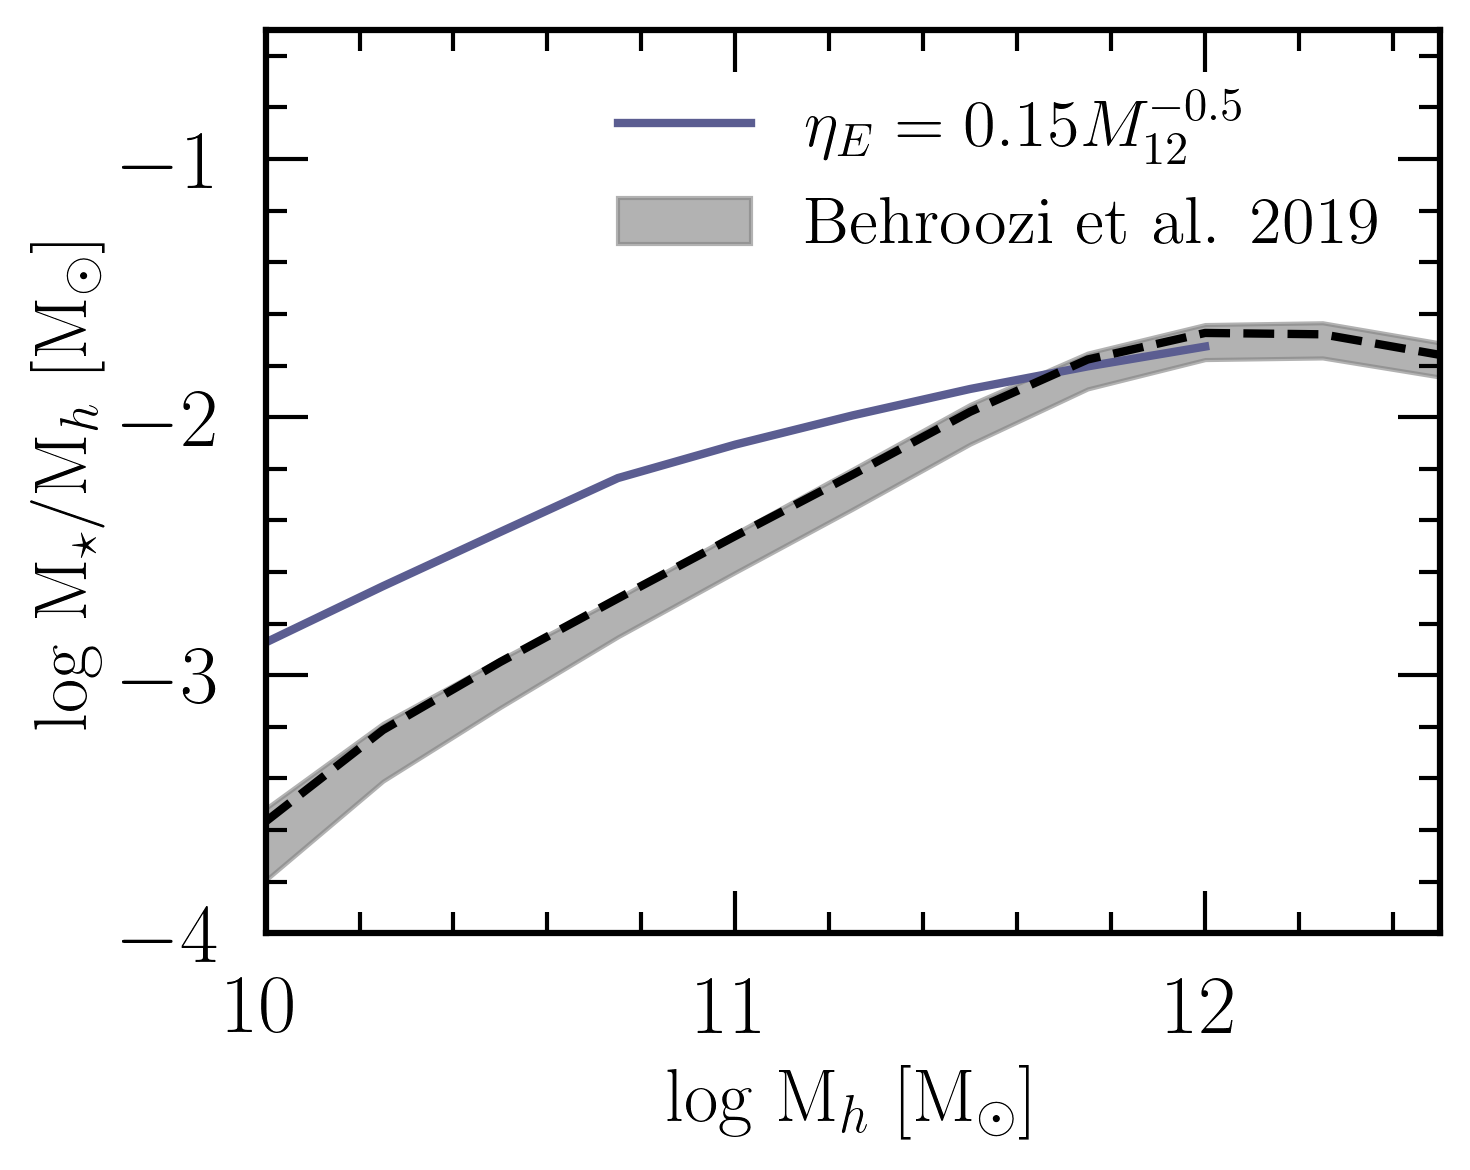

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), sharey="all")

# ax.annotate(r'$\eta_m$ ='+str(1)+', $\eta_Z$ = 0.3',
#               xy=(300, 125), xycoords='figure points', fontsize=20)

ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M4[0, :] / hm[:-4].value),
    color=colors[4],
    label="$\eta_E = 0.15 M_{12}^{-0.5}$",
)
# ax.plot(np.log10(hm[:-4].value), np.log10(mstar_M[0,:]/hm[:-4].value) ,color=colors[1],label='$\eta_m = 1$')
# ax.plot(np.log10(hm[:-4].value), np.log10(mstar_M[2,:]/hm[:-4].value) ,color=colors[3],label='$\eta_m = 3$')
# ax.plot(np.log10(hm[:-4].value), np.log10(mstar_M[3,:]/hm[:-4].value) ,color=colors[3],label='$\eta_m = 10$')


ax.plot(loghm, logSMHM, color="k", ls="--")
ax.fill_between(
    loghm,
    logSMHM + SMHMerr[1, :],
    logSMHM - SMHMerr[0, :],
    color="gray",
    alpha=0.6,
    label="Behroozi et al. 2019",
)
ax.set_xlabel("log M$_h$ [M$_\odot$]", fontsize=18)
ax.set_ylabel("log M$_\star$/M$_h$ [M$_\odot$]", fontsize=18)

ax.set_xlim(10, 12.5)
ax.set_ylim(-4, -0.5)
ax.tick_params(labelsize=20)
# ax.set_title('')

# ax.grid()
ax.legend(fontsize=16)
fig.tight_layout()

In [ ]:
time_interval = (0.1, 1)
zinit = cosmology.z_at_value(LCDM.age, time_interval[0] * u.Gyr)
zfinal = cosmology.z_at_value(LCDM.age, time_interval[1] * u.Gyr)
print("z_init, z_final = ", zinit, zfinal)
nhalos = hm[:-4].size
nlist = 1
mhalo_M5 = np.zeros([nlist, nhalos])
mstar_M5 = np.zeros([nlist, nhalos])
mgas_M5 = np.zeros([nlist, nhalos])
mCGM_M5 = np.zeros([nlist, nhalos])
Zcgm_M5 = np.zeros([nlist, nhalos])
i = 0

for i in range(1):
    j = 0
    for mhalo in tqdm.tqdm(hm[:-4]):
        eta_m = 10 * (mhalo / (1e10 * u.solMass)) ** -0.7
        eta_m = 0.5
        eta_z = 0.3
        eta_e = 0.15 * (mhalo / (1e12 * u.solMass)) ** -0.5
        wind_params = eta_m, eta_e, eta_z
        CB_50 = []
        t, z, mgas_t, mstar_t, mCGM_t, mhalo_t, Z, Eg_t, El_t, Eej_t, Eacc_t, E_CGM = (
            bathtub(time_interval, mhalo)
        )

        # mstar_M_list.append(mstar_t[-1])
        # mgas_M_list.append(mgas_t[-1])
        # mCGM_M_list.append(mCGM_t[-1])
        # Z_M_list.append(Z[-1])
        # CB_M_list.append(CB_50[-1])

        mhalo_M5[i, j] = mhalo.value
        mstar_M5[i, j] = mstar_t[-1]
        mgas_M5[i, j] = mgas_t[-1]
        mCGM_M5[i, j] = mCGM_t[-1]
        Zcgm_M5[i, j] = Z[-1]
        j = j + 1

z_init, z_final =  29.689787031786974 redshift 5.606047443188422 redshift


100%|██████████| 9/9 [00:15<00:00,  1.73s/it]


[[1.00000000e+10 1.77827941e+10 3.16227766e+10 5.62341325e+10
  1.00000000e+11 1.77827941e+11 3.16227766e+11 5.62341325e+11
  1.00000000e+12]] [[0.00934476 0.01551936 0.02465425 0.04066394 0.06235774 0.0764581
  0.09345327 0.11198295 0.13418464]] [[0.02167676 0.02559153 0.02982073 0.03689258 0.04383356 0.0505835
  0.05778795 0.06519253 0.07403481]]


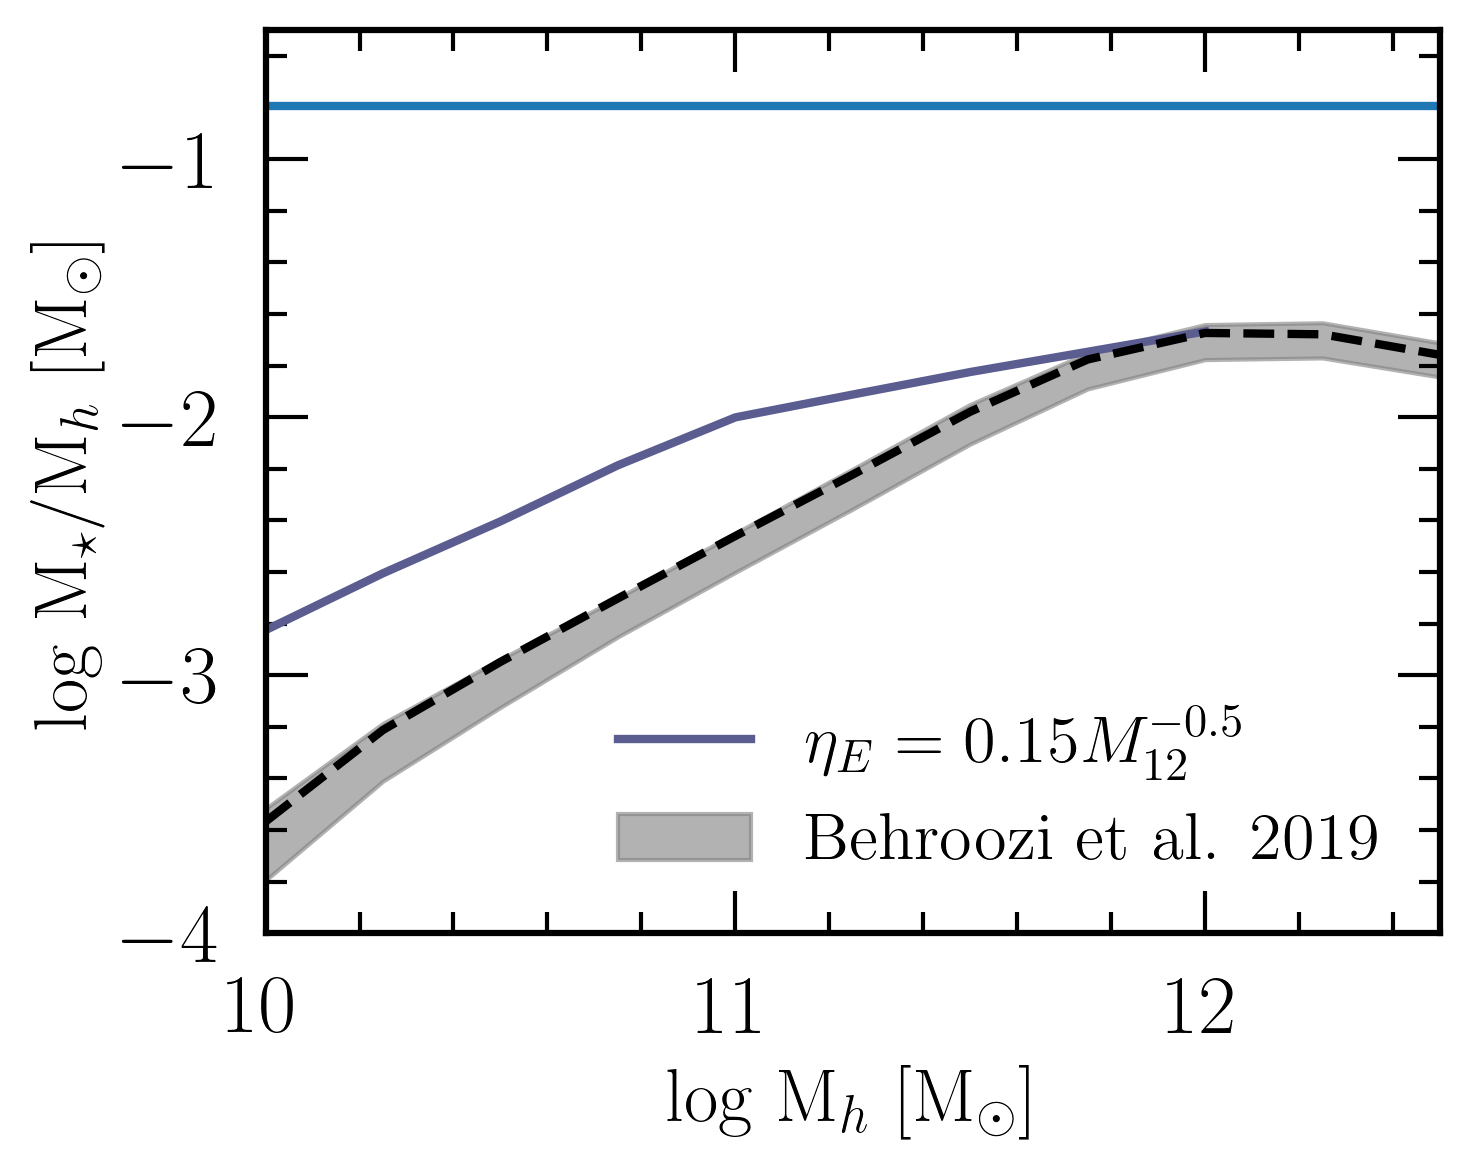

In [ ]:
print(mhalo_M5, mstar_M5 / mhalo_M5 / fb, Zcgm_M5)
fig, ax = plt.subplots(1, 1, figsize=(5, 4), sharey="all")

ax.plot(
    np.log10(hm[:-4].value),
    np.log10(mstar_M5[0, :] / hm[:-4].value),
    color=colors[4],
    label="$\eta_E = 0.15 M_{12}^{-0.5}$",
)
ax.plot([10, 13], 2 * [np.log10(fb)])
ax.plot(loghm, logSMHM, color="k", ls="--")
ax.fill_between(
    loghm,
    logSMHM + SMHMerr[1, :],
    logSMHM - SMHMerr[0, :],
    color="gray",
    alpha=0.6,
    label="Behroozi et al. 2019",
)
ax.set_xlabel("log M$_h$ [M$_\odot$]", fontsize=18)
ax.set_ylabel("log M$_\star$/M$_h$ [M$_\odot$]", fontsize=18)

ax.set_xlim(10, 12.5)
ax.set_ylim(-4, -0.5)
ax.tick_params(labelsize=20)

ax.legend(fontsize=16)
fig.tight_layout()

In [ ]:
mstar_etam_const[i]


NameError: name 'mstar_etam_const' is not defined